# SUPPORT2 Dataset: Data Cleaning & Preparation
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Data Cleaning & Preparation** phase of the project pipeline:

1. Initial data inspection and profiling
1. Column renames per PEP-8
1. Engineering the binary target variable (`death_180d`)
1. Data type casting and ordinal/nominal encoding
1. Missing data analysis and imputation
1. Dropping unused columns
1. Documenting target / feature / outcome 
1. Export of the cleaned dataset for EDA and modeling

---
## Section 0: Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

sys.path.append("../../utils")
from dataset import get_project_root, load_csv

warnings.filterwarnings("ignore")

current = Path.cwd().resolve()

while current != current.parent:
    if (current / ".git").exists() or (current / "pyproject.toml").exists():
        project_root = current
        break
    current = current.parent

PROJ_ROOT = get_project_root()
OUTPUT_PATH = PROJ_ROOT / "data" / "support2_cleaned.csv"
print(f"Output path  : {OUTPUT_PATH}")

Output path  : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv


---
## Section 1: Load Data & Initial Inspection

In [2]:
df_raw = load_csv("support2_raw_complete.csv")
print(f"Shape: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
df_raw.head()

Shape: 9,105 rows  x  48 columns


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [3]:
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        9105 non-null   int64  
 1   age       9105 non-null   float64
 2   death     9105 non-null   int64  
 3   sex       9105 non-null   str    
 4   hospdead  9105 non-null   int64  
 5   slos      9105 non-null   int64  
 6   d.time    9105 non-null   int64  
 7   dzgroup   9105 non-null   str    
 8   dzclass   9105 non-null   str    
 9   num.co    9105 non-null   int64  
 10  edu       7471 non-null   float64
 11  income    6123 non-null   str    
 12  scoma     9104 non-null   float64
 13  charges   8933 non-null   float64
 14  totcst    8217 non-null   float64
 15  totmcst   5630 non-null   float64
 16  avtisst   9023 non-null   float64
 17  race      9063 non-null   str    
 18  sps       9104 non-null   float64
 19  aps       9104 non-null   float64
 20  surv2m    9104 non-null   float64
 21  su

In [4]:
int_cols = df_raw.select_dtypes(include="int64").columns
binary_cols = [
    c
    for c in int_cols
    if df_raw[c].nunique() == 2 and set(df_raw[c].unique()) == {0, 1}
]
print("===========Binary Columns==========")
print(binary_cols)

===========Binary Columns==========
['death', 'hospdead', 'diabetes', 'dementia']


### 1.1 Descriptive Statistics

In [5]:
desc = df_raw.describe().T
desc.columns = [
    "Count",
    "Mean",
    "Std Dev",
    "Min",
    "Q1 (25%)",
    "Median (50%)",
    "Q3 (75%)",
    "Max",
]
desc

,Count,Mean,Std Dev,Min,Q1 (25%),Median (50%),Q3 (75%),Max
id,9105.0,4553.000000,2628.531434,1.000000,2277.000000,4553.000000,6829.000000,9.105000e+03
age,9105.0,62.650823,15.593710,18.041990,52.797000,64.856990,73.998960,1.018480e+02
death,9105.0,0.681054,0.466094,0.000000,0.000000,1.000000,1.000000,1.000000e+00
hospdead,9105.0,0.259198,0.438219,0.000000,0.000000,0.000000,1.000000,1.000000e+00
slos,9105.0,17.863042,22.006440,3.000000,6.000000,11.000000,20.000000,3.430000e+02
d.time,9105.0,478.449863,560.383272,3.000000,26.000000,233.000000,761.000000,2.029000e+03
num.co,9105.0,1.868644,1.344409,0.000000,1.000000,2.000000,3.000000,9.000000e+00
edu,7471.0,11.747691,3.447743,0.000000,10.000000,12.000000,14.000000,3.100000e+01
scoma,9104.0,12.058546,24.636694,0.000000,0.000000,0.000000,9.000000,1.000000e+02
charges,8933.0,59995.787811,102648.778198,1169.000000,9740.000000,25024.000000,64598.000000,1.435423e+06


---
## Section 2: Column Renaming

Rename some columsn to follow PEP-8 standard

In [6]:
rename_map = {
    "d.time": "d_time",
    "num.co": "num_co",
}
df = df_raw.rename(columns=rename_map).copy()

print("Column renames applied:")
for old, new in rename_map.items():
    print(f"  {old!r}  ->  {new!r}")
print(f"\nTotal columns: {len(df.columns)}")

Column renames applied:
  'd.time'  ->  'd_time'
  'num.co'  ->  'num_co'

Total columns: 48


---
## Section 3: Target Variable

**Did the patient die within 180 days of study?**

To answer this we look at two fields: 
- `death`:  whether the patient ever died during 180 days (1 = yes, 0 = no)
- `d_time`:  days of follow-up (how long they were observed). If this number is greater than 180 days of the trial, that means they survived the trial

death_180d (1 = yes, 0 = no) = {death=1 AND d_time <= 180}

Notice the AND conditional because the patient must've died within the 180 days to satisfy our target. 
We then use **death_180d** for binary classification


In [7]:
df["death_180d"] = ((df["death"] == 1) & (df["d_time"] <= 180)).astype(int)

counts = df["death_180d"].value_counts()
rel_freqs = df["death_180d"].value_counts(normalize=True)

summary = pd.DataFrame(
    {
        "Outcome": ["Survived >= 180 days (0)", "Died within 180 days (1)"],
        "Frequency": counts.values,
        "Relative Frequency": rel_freqs,
        "Percentage (%)": (rel_freqs.values * 100),
    }
)
print(summary.to_string(index=False))
print(f"\nClass imbalance ratio (survived: died) = {counts[0] / counts[1]:.2f} : 1")

                 Outcome  Frequency  Relative Frequency  Percentage (%)
Survived >= 180 days (0)       4840            0.531576       53.157606
Died within 180 days (1)       4265            0.468424       46.842394

Class imbalance ratio (survived: died) = 1.13 : 1


---
## Section 4: Data Type Casting (into Pandas Type)

Correct data types are essential for proper computing and modeling.
We apply three categories of correction. Casting to Int8 also handles NaN gracefully:

1. **Binary integer columns** -> `Int8` (nullable integer; memory-efficient)
2. **Nominal categorical columns** -> unordered `pd.Categorical`
3. **Ordinal categorical columns** -> ordered `pd.Categorical` for proper sorting and comparision

**`income` ordering (ascending socioeconomic status):**
`under $11k` < `$11-$25k` < `$25-$50k` < `>$50k`

**`sfdm2` ordering (best functional status → worst):**
`no disability` < `moderate ADL impairment` < `severe SIP impairment` < `coma/intubated` < `died before 2-month interview`

In [8]:
# Binary columns -> nullable Int8
binary_cols = ["death", "hospdead", "diabetes", "dementia"]
for col in binary_cols:
    df[col] = df[col].astype("Int8")

######  8 Catagoricals
# sex = 2 levels
# dzgroup = 5
# dzclass = 4
# race = 5
# income = 4
# ca = 3
# dnr = 3
# sfdm2 = 5
##############

# Nominal (unordered) categoricals
nominal_cats = ["sex", "dzgroup", "dzclass", "race", "ca", "dnr"]
for col in nominal_cats:
    df[col] = df[col].astype("category")

# Ordinal: income (lowest -> highest bracket) as coded in support2_data_dictionary.md
income_order = ["under $11k", "$11-$25k", "$25-$50k", ">$50k"]
df["income"] = pd.Categorical(df["income"], categories=income_order, ordered=True)

# Ordinal: sfdm2 (2-month functional disability; no disability -> died before interview)
# as coded in support2_data_dictionary.md
sfdm2_order = [
    "no(M2 and SIP pres)",  # Level 1 - no moderate/severe disability
    "adl>=4 (>=5 if sur)",  # Level 2 - unable to do 4+ ADL
    "SIP>=30",  # Level 3 - Sickness Impact Profile >= 30
    "Coma or Intub",  # Level 4 - intubated or in coma at 2 months
    "<2 mo. follow-up",  # Level 5 - died before 2-month interview
]
df["sfdm2"] = pd.Categorical(df["sfdm2"], categories=sfdm2_order, ordered=True)

print("Data type corrections applied:\n")
cols_updated = binary_cols + nominal_cats + ["income", "sfdm2"]
print(df[cols_updated].dtypes.to_string())

Data type corrections applied:

death           Int8
hospdead        Int8
diabetes        Int8
dementia        Int8
sex         category
dzgroup     category
dzclass     category
race        category
ca          category
dnr         category
income      category
sfdm2       category


---
## Section 5: Missing Data Analysis

The authors have stated there are a maximum of 5641 N/As. This, along with every other missing data, we must verify and address.


In [9]:
missing_count = df.isnull().sum()
missing_percent = missing_count / len(df) * 100
missing_df = pd.DataFrame(
    {
        "Missing Count": missing_count,
        "Missing %": missing_percent,
    }
).sort_values("Missing Count", ascending=False)

missing_df = missing_df[missing_df["Missing Count"] > 0]

total_cells = df.shape[0] * df.shape[1]
total_missing = int(missing_df["Missing Count"].sum())

print(f"Columns with at least one missing value : {len(missing_df)}")
print(
    f"Total missing cells : {total_missing:,} / {total_cells:,}  ({total_missing / total_cells * 100:.1f}%)\n"
)
print(missing_df.to_string())

# verify maximum missing n/as
max_na = df_raw.isnull().sum().max()
max_na_col = df_raw.isnull().sum().idxmax()
print(f"Max NAs: {max_na} (column: '{max_na_col}')")
assert max_na == 5641, f"Expected 5641, got {max_na}"

Columns with at least one missing value : 33
Total missing cells : 47,110 / 446,145  (10.6%)

         Missing Count  Missing %
adlp              5641  61.954970
urine             4862  53.399231
glucose           4500  49.423394
bun               4352  47.797913
totmcst           3475  38.165843
alb               3372  37.034596
income            2982  32.751236
adls              2867  31.488193
bili              2601  28.566722
pafi              2325  25.535420
ph                2284  25.085118
prg2m             1649  18.110928
edu               1634  17.946183
prg6m             1633  17.935200
sfdm2             1400  15.376167
totcst             888   9.752883
wblc               212   2.328391
charges            172   1.889072
avtisst             82   0.900604
crea                67   0.735859
race                42   0.461285
dnrday              30   0.329489
dnr                 30   0.329489
sps                  1   0.010983
aps                  1   0.010983
sod                  1

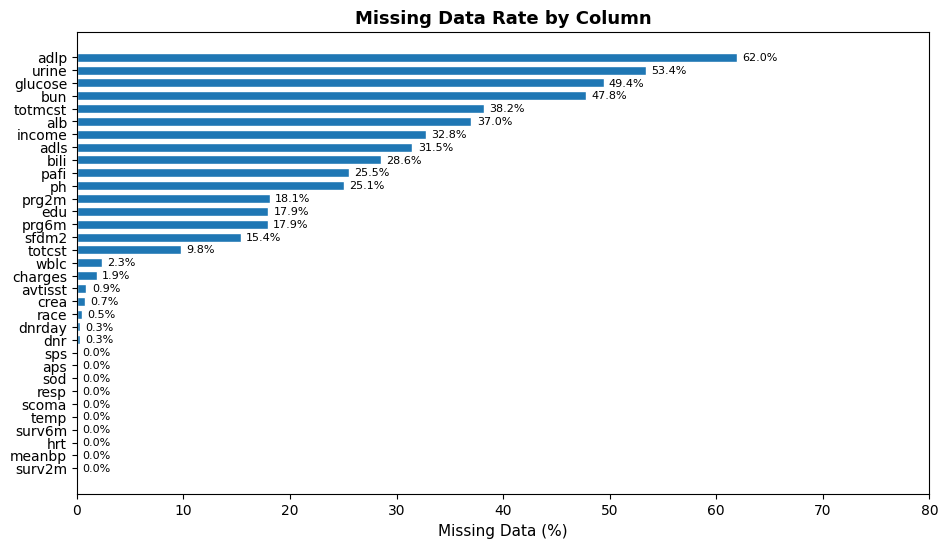

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    missing_df.index[::-1],
    missing_df["Missing %"][::-1],
    edgecolor="white",
    height=0.7,
)


ax.set_xlabel("Missing Data (%)", fontsize=11)
ax.set_title("Missing Data Rate by Column", fontsize=13, fontweight="bold")
ax.set_xlim(0, 80)

for bar, pct in zip(bars, missing_df["Missing %"][::-1]):
    if pct > 0:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center",
            fontsize=8,
        )
plt.show()

### 5.1 Missing Data Decision Table

Here we decide how to tackle missing data. Either drop the column entirely or impute mathematically

For most of our biological features that have missing data, we compute the median. The reason is per Agresti et al (2022), chapter 3, that for right-skewed data, using median instead of mean worse the skewness of the data (push it woard the tail). Looking at section 1, our columns the mean > median, which signals right skewed.



| Column(s) | Decision | Rationale |
|---|---|---|
| `adlp`, `adls` | **Drop** | Superseded by `adlsc` per original authors
| `dnrday` | **Drop** | Do-no-resus day. Useless for our purpose
| `hday` | **Drop** | Day admitted to study. Nothing to do with mortality
| `charges, totcst, totmcst` | **Drop** | Relating to hospital cost, which we won't be studying
| `alb`, `pafi`, `bili`, `crea`, `bun`, `wblc`, `urine` | **imputed values avail** | Per Author's note we have the recommended imputed values
| `ph`, `glucose`, `scoma`, `avtisst`, `edu`, `prg2m`, `prg6m`  | **Sample median** | high missing |
| `surv2m`, `surv6m`, `aps`, | **Sample median** | kept as benchmark columns |
| `meanbp`, `hrt`, `resp`, `temp`, `sod` | **Sample median** | few missing |
| `charges`, `totcst` |  **Sample median** | Retained for future cost analysis |
| `totmcst` | **Sample median** | Retained for future cost analysis; many missing values and will be difficult to impute. Contains negative values (balances) |
| `race`, `income`, `sfdm2`, `dnr` | **Mode imputation** | Most frequent category as best single-value estimate for categoricals |

#### Benchmark Columns (kept but will be excluded from death_180d model features)

| Column | Role | Notes |
|---|---|---|
| `surv2m`, `surv6m` | SUPPORT model predictions | will be compared against our model |
| `aps` | APACHE III severity score | Independent benchmark system widely used in critical care |
| `sps` | SUPPORT physiology sub-score | Component of the SUPPORT model ?? |
| `prg2m`, `prg6m` | Physician survival estimates | ML vs. clinician judgment comparison |
| `dnr` | DNR order status | **Should not use as predictor feature as it's reflects human behavior rather than biological factors** |

---
## Section 6: Feature Pruning

We remove features not used in our analysis:

In [11]:
cols_to_drop = ["adlp", "adls", "dnrday"]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
print(f"Dropped  : {len(cols_to_drop)} columns")
print(f"Remaining: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Remaining columns ({df.shape[1]}):")
print(list(df.columns))

Dropped  : 3 columns
Remaining: 9,105 rows  x  46 columns
Remaining columns (46):
['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd_time', 'dzgroup', 'dzclass', 'num_co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'sfdm2', 'adlsc', 'death_180d']


---
## Section 7: Missing Data Imputation

The original SUPPORT study authors (Harrell, 2022) provide clinically validated
**normal fill-in values** for seven physiological variables (see docs/support2_dataset_description.md).
We will use this for imputation

| Variable | Normal Fill | Meaning |
|---|---|---|
| `alb`   | 3.5   | Serum albumin - liver / nutrition |
| `pafi`  | 333.3 | PaO2/FiO2 ratio - oxygen level|
| `bili`  | 1.01  | Bilirubin - liver function |
| `crea`  | 1.01  | Creatinine - renal function |
| `bun`   | 6.51  | BUN - normal renal function |
| `wblc`  | 9.0   | WBC count - immune status |
| `urine` | 2502  | Urine output - renal output |

In [12]:
DOMAIN_FILL = {
    "pafi": 333.3,
    "bili": 1.01,
    "crea": 1.01,
    "bun": 6.51,
    "wblc": 9.0,
    "urine": 2502.0,
}

# KNN imputation for albumin
# Rationale: albumin has 37% missingness and is a clinically important mortality
# predictor (Knaus et al., 1995). The domain fill value of 3.5 coincides with
# the Q3 boundary, collapsing quartile bins and making albumin unusable as a
# stratification variable in interaction analysis. KNN imputation (k=5) preserves
# realistic variation by borrowing from physiologically similar patients rather
# than substituting a single normal value uniformly across all missing cases.
# Features used for neighbor calculation: age, meanbp, hrt, resp, temp, sod;
# these are variables with low missingness that capture overall physiologic status.

alb_features = ["alb", "age", "meanbp", "hrt", "resp", "temp", "sod"]
knn_imputer = KNNImputer(n_neighbors=5)

df_alb = df[alb_features].copy()
df_alb_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_alb), columns=alb_features, index=df.index
)
df["alb"] = df_alb_imputed["alb"]

# Verify
print(f"Albumin missing after KNN imputation: {df['alb'].isnull().sum()}")
print(df["alb"].describe().round(3))

imputation_log = []

for k, v in DOMAIN_FILL.items():
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        df[k] = df[k].fillna(v)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Domain Fill",
                "Fill Value": v,
                "Cells Filled": n_missing,
            }
        )

MEDIAN_COLS = [
    "sps",
    "charges",
    "totcst",
    "totmcst",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "sod",
    "ph",
    "glucose",
    "scoma",
    "avtisst",
    "edu",
    "surv2m",
    "surv6m",
    "aps",
    "prg2m",
    "prg6m",
]
for k in MEDIAN_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        med = float(df[k].median())
        df[k] = df[k].fillna(med)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Median",
                "Fill Value": round(med, 4),
                "Cells Filled": n_missing,
            }
        )

MODE_COLS = ["race", "income", "sfdm2", "dnr"]

for k in MODE_COLS:
    n_missing = int(df[k].isnull().sum())
    if n_missing > 0:
        mode_val = df[k].mode()[0]
        df[k] = df[k].fillna(mode_val)
        imputation_log.append(
            {
                "Column": k,
                "Strategy": "Sample Mode",
                "Fill Value": str(mode_val),
                "Cells Filled": n_missing,
            }
        )

log_df = pd.DataFrame(imputation_log)
print("Imputation Summary:")
print(log_df.to_string(index=False))
print(f"Total cells imputed: {log_df.get('Cells Filled', np.array([])).sum():,}")

Albumin missing after KNN imputation: 0
count    9105.000
mean        2.983
std         0.752
min         0.400
25%         2.500
50%         2.960
75%         3.400
max        29.000
Name: alb, dtype: float64
Imputation Summary:
 Column      Strategy       Fill Value  Cells Filled
   pafi   Domain Fill            333.3          2325
   bili   Domain Fill             1.01          2601
   crea   Domain Fill             1.01            67
    bun   Domain Fill             6.51          4352
   wblc   Domain Fill              9.0           212
  urine   Domain Fill           2502.0          4862
    sps Sample Median          23.8984             1
charges Sample Median          25024.0           172
 totcst Sample Median       14452.7344           888
totmcst Sample Median          13223.5          3475
 meanbp Sample Median             77.0             1
    hrt Sample Median            100.0             1
   resp Sample Median             24.0             1
   temp Sample Median       

In [13]:
remaining_na = df.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]

if len(remaining_na) == 0:
    print("Imputation complete, zero missing values remain in any column.")
else:
    print("WARNING: Remaining missing values:")
    print(remaining_na.to_string())

print(
    f"\nDataset shape after imputation: {df.shape[0]:,} rows  x  {df.shape[1]} columns"
)

Imputation complete, zero missing values remain in any column.

Dataset shape after imputation: 9,105 rows  x  46 columns


In [14]:
# ── Section 7.1: Physiologic Range Validation & Outlier Treatment ──────────
#
# Imputation addressed missingness but did not handle physiologically
# implausible values carried in the raw data. Two strategies are applied:
#
# Strategy 1 — Replace zero vital sign values with physiologic normal values
# Zero values in meanbp, hrt, and resp are treated as invalid measurements
# rather than true physiologic readings. Per Knaus et al. (1991), the APACHE III
# system substitutes normal values when physiologic measurements are missing or
# invalid. We apply the same approach here using dataset medians as normal
# reference values.
#
# Note: 103 rows contain at least one zero vital sign. Analysis shows 65% death
# rate among these rows vs 46.8% overall, and zeros are distributed across all
# three vital signs rather than concentrated in one column, suggesting mixed
# causes (measurement error, device artifact, recording error) rather than
# exclusively post-mortem recordings.
#
# References:
# Knaus et al. (1991). The APACHE III prognostic system. Chest, 100(6), 1619-1636.
# Knaus et al. (1995). The SUPPORT prognostic model. Ann Intern Med, 122(3), 191-203.
#
# Strategy 2 — Winsorize lab and physiologic variables
# Values outside established physiologic limits are capped at the boundary
# rather than dropped, preserving sample size while eliminating impossible
# values. Limits are based on published physiologic reference ranges.

# --- Strategy 1: Replace zero vital sign values with physiologic normal values ---
vital_fills = {
    "meanbp": df["meanbp"][df["meanbp"] > 0].median(),
    "hrt": df["hrt"][df["hrt"] > 0].median(),
    "resp": df["resp"][df["resp"] > 0].median(),
}

for col, fill_val in vital_fills.items():
    n_zeros = (df[col] == 0).sum()
    if n_zeros > 0:
        df[col] = df[col].replace(0, fill_val)
        print(f"{col}: {n_zeros} zeros replaced with {fill_val:.1f}")

print(f"\nDataset shape unchanged: {df.shape[0]:,} rows x {df.shape[1]} columns")

# --- Strategy 2: Winsorize physiologic variables ---
phys_limits = {
    "meanbp": (1, 200),  # mmHg
    "hrt": (1, 250),  # bpm
    "resp": (1, 60),  # breaths/min
    "temp": (25, 42),  # Celsius
    "sod": (100, 170),  # mEq/L
    "glucose": (20, 600),  # mg/dL
    "bun": (0, 150),  # mg/dL
    "wblc": (0, 50),  # thousands/uL
    "pafi": (50, 600),  # ratio
    "urine": (0, 8000),  # mL/day
}

print("\nWinsorization summary:")
total_capped = 0
for col, (lo, hi) in phys_limits.items():
    if col not in df.columns:
        continue
    n_capped = int(((df[col] < lo) | (df[col] > hi)).sum())
    if n_capped > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        print(f"  {col}: {n_capped} values capped to [{lo}, {hi}]")
        total_capped += n_capped

print(f"\nTotal values winsorized: {total_capped}")
print(f"Final dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

meanbp: 51 zeros replaced with 78.0
hrt: 83 zeros replaced with 100.0
resp: 65 zeros replaced with 24.0

Dataset shape unchanged: 9,105 rows x 46 columns

Winsorization summary:
  hrt: 1 values capped to [1, 250]
  resp: 9 values capped to [1, 60]
  sod: 3 values capped to [100, 170]
  glucose: 25 values capped to [20, 600]
  bun: 11 values capped to [0, 150]
  wblc: 66 values capped to [0, 50]
  pafi: 58 values capped to [50, 600]
  urine: 12 values capped to [0, 8000]

Total values winsorized: 185
Final dataset shape: 9,105 rows x 46 columns


In [15]:
# Verify target variable balance after row drops
counts = df["death_180d"].value_counts()
print("\nUpdated class balance:")
print(f"Survived >= 180 days: {counts[0]:,} ({counts[0]/len(df):.1%})")
print(f"Died within 180 days: {counts[1]:,} ({counts[1]/len(df):.1%})")


Updated class balance:
Survived >= 180 days: 4,840 (53.2%)
Died within 180 days: 4,265 (46.8%)


---
## Section 8: Defining Feature, Outcome Separation, Leakage 

| Category | Columns |
|---|---|
| **Target** | `death_180d` |
| **Outcome columns** (excluded due to result leakage) | `death`, `hospdead`, `d_time`, `slos` |
| **Row identifier** | `id` | 
| **Features** | All remaining columns | 

---
## Section 9: Post-Cleaning Summary

We compare the dataset before and after cleaning and present the five-number
summary for key physiological lab variables to confirm that imputation and
outlier retention produced a coherent, analysis-ready dataset.

In [16]:
print("=== Pre-Cleaning ===")
print(f"  Shape          : {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
print(f"  Missing cells  : {df_raw.isnull().sum().sum():,}")

print("\n=== Post-Cleaning ===")
print(f"  Shape          : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"  Missing cells  : {df.isnull().sum().sum()}")
print(f"  Rows retained  : {df.shape[0] / df_raw.shape[0] * 100:.1f}%")

prev = df["death_180d"].mean()

=== Pre-Cleaning ===
  Shape          : 9,105 rows  x  48 columns
  Missing cells  : 47,110

=== Post-Cleaning ===
  Shape          : 9,105 rows  x  46 columns
  Missing cells  : 0
  Rows retained  : 100.0%


### 9.1 Important Lab Variables Summary (Post-Cleaning)

In [17]:
key_labs = [
    "age",
    "meanbp",
    "hrt",
    "temp",
    "alb",
    "bili",
    "crea",
    "glucose",
    "bun",
    "urine",
]
post_desc = df[key_labs].describe().T
post_desc.columns = ["Count", "Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max"]
post_desc[["Min", "Q1", "Median", "Q3", "Max", "Mean", "Std Dev"]]

,Min,Q1,Median,Q3,Max,Mean,Std Dev
age,18.041990,52.797000,64.856990,73.998960,101.84796,62.650823,15.593710
meanbp,5.000000,64.000000,78.000000,107.000000,195.00000,84.982482,26.954352
hrt,1.000000,72.000000,100.000000,120.000000,250.00000,98.063119,30.118448
temp,31.699220,36.195310,36.695310,38.195310,41.69531,37.103296,1.251734
alb,0.399963,2.500000,2.959766,3.399902,29.00000,2.982519,0.751791
bili,0.099991,0.599976,1.010000,1.299805,63.00000,2.113261,4.548787
crea,0.099991,0.899902,1.199951,1.899902,21.50000,1.765361,1.681084
glucose,20.000000,133.000000,135.000000,136.000000,600.00000,147.303460,61.248515
bun,1.000000,6.510000,6.510000,24.000000,150.00000,19.963044,23.001330
urine,0.000000,2075.000000,2502.000000,2502.000000,8000.00000,2356.712781,1001.687658


#### 9.2 Target Variable Validation

The `death_180d` target is valid only if `d_time` is measured from study admission 
consistently across all patients. Two checks were performed to confirm this.

**Check 1 — Admission reference point:** For all 2,360 patients who died in hospital 
(`hospdead = 1`), `d_time` minus `slos` (length of stay) equals exactly zero across 
every patient (mean = 0.0, std = 0.0, max = 0.0). This confirms `d_time` is 
admission-referenced with no exceptions.

**Check 2 — Target variable integrity:** All 4,265 patients classified as 
`death_180d = 1` have `d_time <= 180` (max = 180). No patient is incorrectly 
flagged. The median `d_time` of 23 days among this group indicates that most 
180-day deaths in this dataset are early and acute rather than gradual.

Both checks pass. The `death_180d` target variable is correctly constructed and 
suitable for modeling.

In [18]:
# Patients who died in hospital should have d_time = slos (length of stay)
# or very close to it
hospdead_patients = df[df["hospdead"] == 1]
assert (
    hospdead_patients["d_time"] == hospdead_patients["slos"]
).all(), "d_time mismatch detected"
print("Check passed: d_time == slos for all in-hospital deaths")

Check passed: d_time == slos for all in-hospital deaths


In [19]:
# d_time for death_180d=1 patients should all be <= 180
died_180 = df[df["death_180d"] == 1]
print(died_180["d_time"].describe().to_string())

count    4265.000000
mean       42.994138
std        45.721409
min         3.000000
25%         9.000000
50%        23.000000
75%        63.000000
max       180.000000


---
## Section 10: Save Cleaned Dataset

In [20]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to : {OUTPUT_PATH}")
print(f"Final shape              : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print("\nColumn list and dtypes:")
print(df.dtypes.to_string())

Cleaned dataset saved to : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_cleaned.csv
Final shape              : 9,105 rows  x  46 columns

Column list and dtypes:
id               int64
age            float64
death             Int8
sex           category
hospdead          Int8
slos             int64
d_time           int64
dzgroup       category
dzclass       category
num_co           int64
edu            float64
income        category
scoma          float64
charges        float64
totcst         float64
totmcst        float64
avtisst        float64
race          category
sps            float64
aps            float64
surv2m         float64
surv6m         float64
hday             int64
diabetes          Int8
dementia          Int8
ca            category
prg2m          float64
prg6m          float64
dnr           category
meanbp         float64
wblc           float64
hrt            float64
resp           float64
temp           float64
pafi           float64


# SUPPORT2 Dataset: Exploratory Data Analysis
**AAI-500 Applied Statistics for AI | Final Team Project**

---

## Notebook Objectives

This notebook covers the **Exploratory Data Analysis** phase of the project pipeline:

1. Detect Outliers
1. Univariate Analysis
1. Bivariate Analsysis
1. Demographic Analsysis
1. Disease Group Analysis
1. DNR Status Analysis

# 

---
# Learnings from the 1990s study
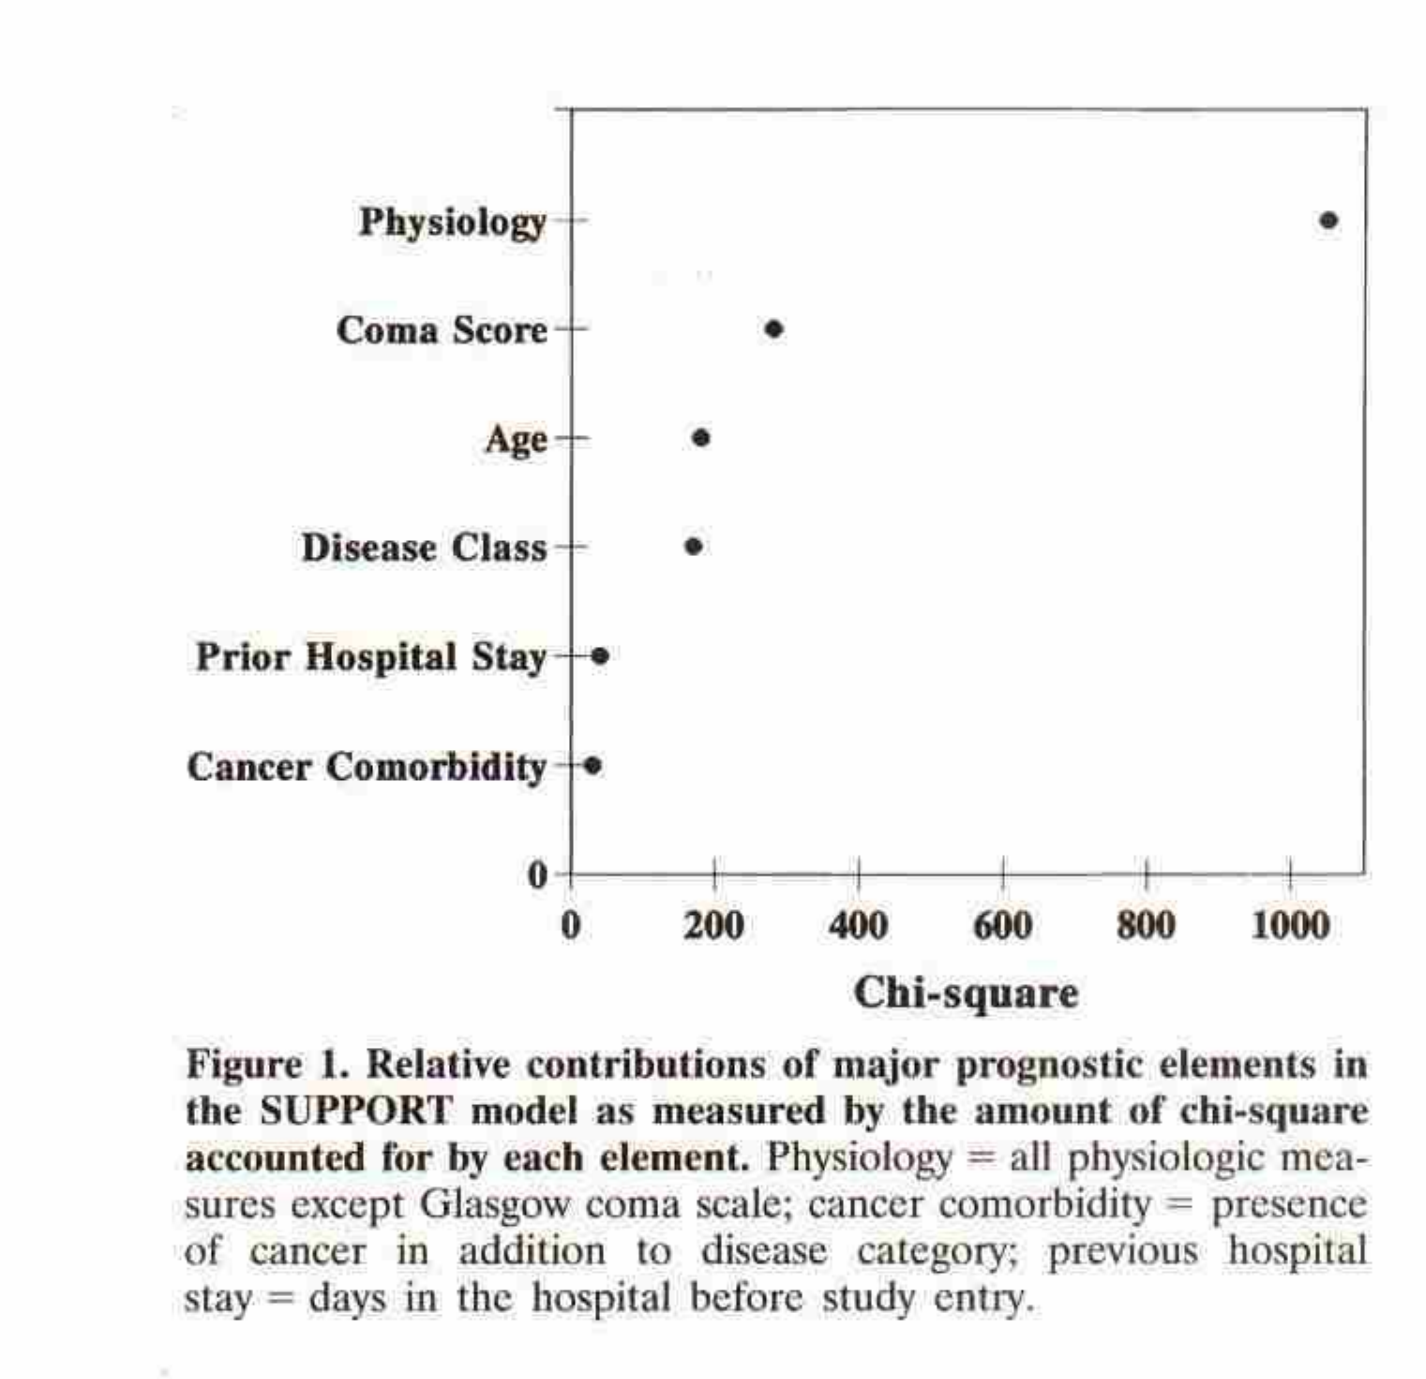
To inform our work, we review Knaus et al's (1995) paper.
According to Knaus et al these features were most weighted in their model:
- Physiology Score (calculated from wbc, albumin, etc). Some salient ones are Blood Pressure and Oxygenation levels
- Neurological Function (Glasgow coma scale)
- Patient age (but only when coupled with certain diseases like COPD)
- Apache III score
- Disease-Specific Interactions: The mathematical weight of certain features was explicitly programmed to vary based on the patient's primary disease:Albumin x Disease: A low albumin level strongly predicted death in cancer, COPD, and congestive heart failure, but was relatively unimportant in coma or MOSF.  WBC x Disease: A low WBC count was specifically associated with a greater risk of death in acute respiratory failure and MOSF.  Age x Disease: Advancing age heavily impacted short-term survival in COPD but had almost no incremental effect on patients with severe acute complications like MOSF or malignancy.  

---
## Section 0: Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score

_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))

from utils.dataset import load_csv  # noqa: E402

warnings.filterwarnings("ignore")

---
## Section 1: Load Cleaned Data

In [2]:
df = load_csv("support2_cleaned.csv")
print(f"Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")

OUTCOME_COLS = ["death", "hospdead", "d_time", "slos"]
ID_COLS = ["id"]
TARGET_COL = "death_180d"
BENCHMARK_COLS = ["surv2m", "surv6m", "aps", "sps", "prg2m", "prg6m", "dnr"]
LAB_COLS = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
]
FEATURE_COLS = [
    c
    for c in df.columns
    if c not in OUTCOME_COLS + ID_COLS + [TARGET_COL] + BENCHMARK_COLS
]

survivors = df[df[TARGET_COL] == 0]
died = df[df[TARGET_COL] == 1]
overall_rate = df[TARGET_COL].mean()
print(f"Survived 180d   : {len(survivors):,}  ({1 - overall_rate:.1%})")
print(f"Died within 180d: {len(died):,}  ({overall_rate:.1%})")

Shape: 9,105 rows  x  46 columns
Survived 180d   : 4,840  (53.2%)
Died within 180d: 4,265  (46.8%)


---
## Section 2: Physiology Outlier Detection (IQR Method)

```
IQR = Q3 - Q1
Lo whisker = Q1 - 1.5IQR
Hi whisker = Q3 + 1.5IQR
```

- Urine boxplot median is pushed all the way right because of imputation with Norm-Fill. 
- Glucose boxplot collapses due to high number of imputed NAs.
- **Probably better to run outliers before imputation**

In [3]:
def compute_iqr_outliers(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = int(((df[col] < lo) | (df[col] > hi)).sum())
        rows.append(
            {
                "Column": col,
                "Q1": round(float(Q1), 3),
                "Q3": round(float(Q3), 3),
                "IQR": round(float(IQR), 3),
                "Lo Whisker": round(float(lo), 3),
                "Hi Whisker": round(float(hi), 3),
                "Outliers": outliers,
                "Outlier %": round(outliers / len(df) * 100, 1),
            }
        )
    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)


outlier_df = compute_iqr_outliers(df, LAB_COLS)
print(
    outlier_df[
        ["Column", "Lo Whisker", "Hi Whisker", "Outliers", "Outlier %"]
    ].to_string(index=False)
)

 Column  Lo Whisker  Hi Whisker  Outliers  Outlier %
glucose     128.500     140.500      4323       47.5
  urine    1434.500    3142.500      2361       25.9
   bili      -0.450       2.350      1397       15.3
     ph       7.325       7.524      1107       12.2
   crea      -0.600       3.400       987       10.8
    bun     -19.725      50.235       916       10.1
   wblc      -5.149      27.249       431        4.7
    sod     123.500     151.500       256        2.8
   resp       3.000      43.000       248        2.7
    alb       1.150       4.750        68        0.7
   pafi     -49.950     563.250        59        0.6
    hrt       0.000     192.000        40        0.4
   temp      33.195      41.195        14        0.2
 meanbp      -0.500     171.500         9        0.1


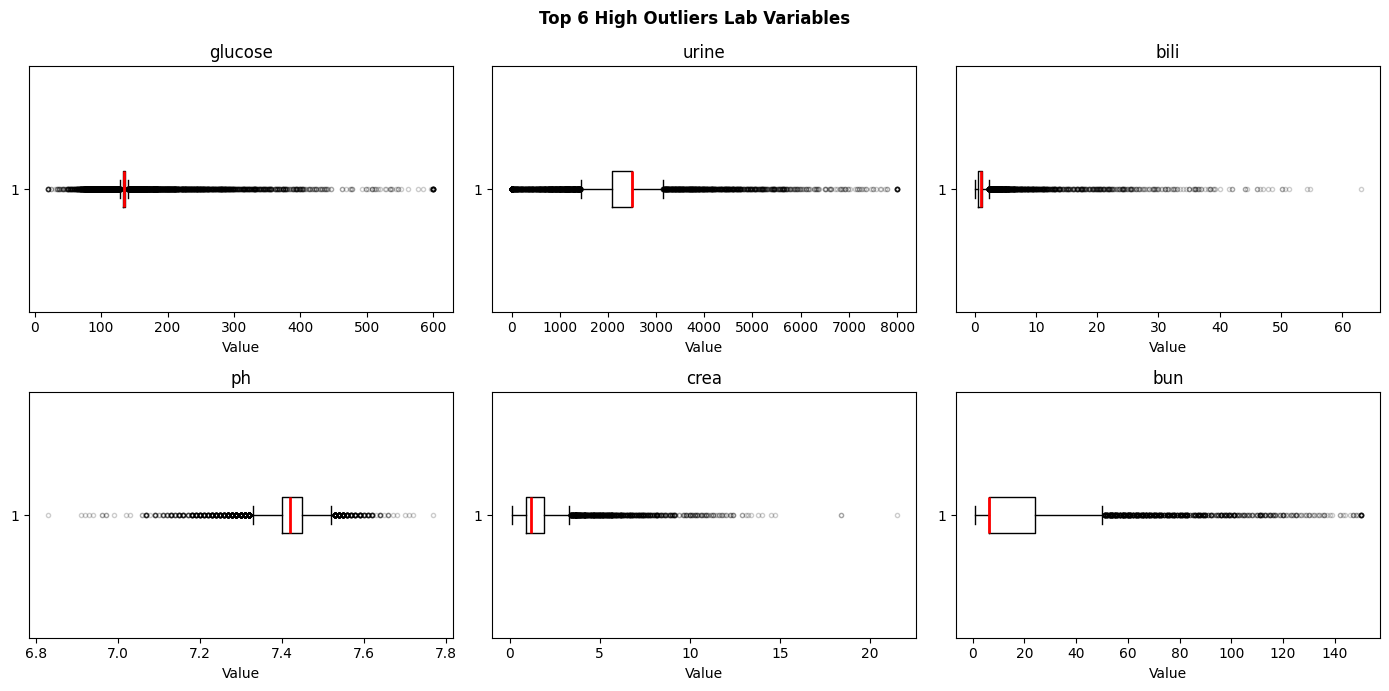

In [4]:
top6 = outlier_df.head(6)["Column"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(top6):
    axes.flat[i].boxplot(
        df[col],
        vert=False,
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", alpha=0.2, markersize=3, color="gray"),
    )
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
fig.suptitle("Top 6 High Outliers Lab Variables", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 3: Univariate Distributions

- Lab features are mainly right skewed
- Some imputations cause spikeness (glucose, pafi, bili)

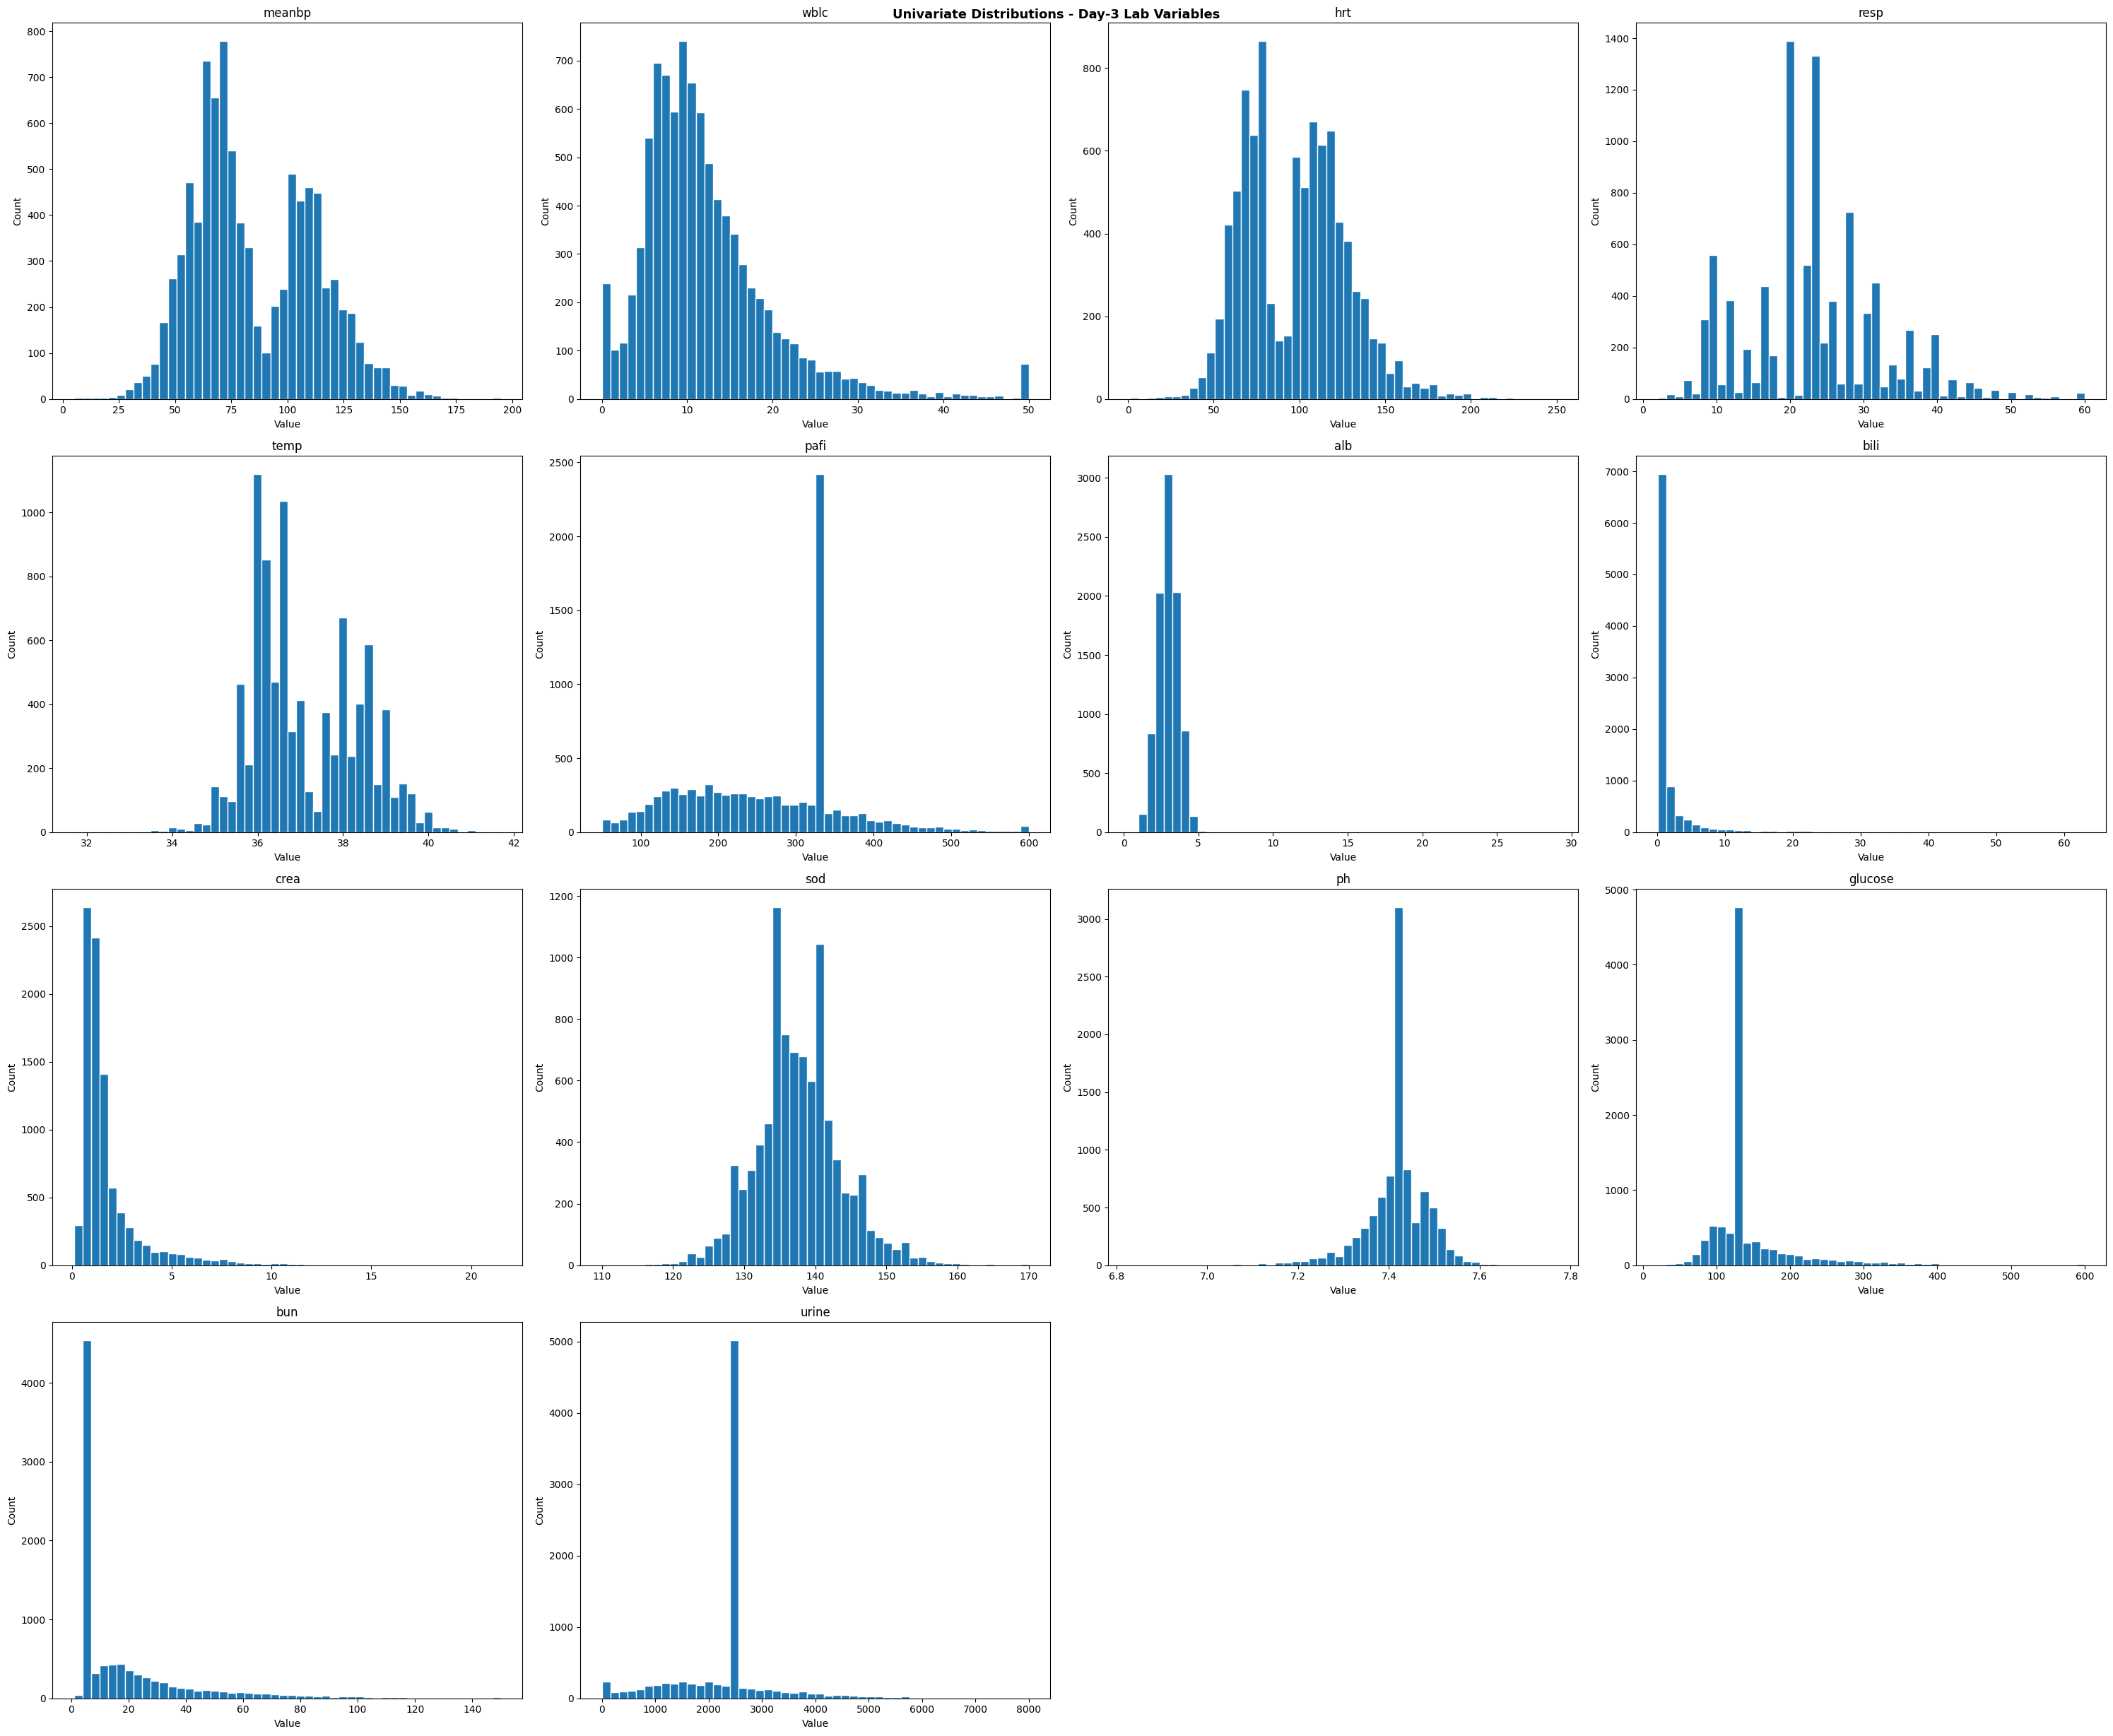

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(30, 25))
for i, col in enumerate(LAB_COLS):
    axes.flat[i].hist(df[col], bins=50, edgecolor="white")
    axes.flat[i].set_title(col)
    axes.flat[i].set_xlabel("Value")
    axes.flat[i].set_ylabel("Count")
for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)
fig.suptitle(
    "Univariate Distributions - Day-3 Lab Variables", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 3.1 Age follows normal distribution

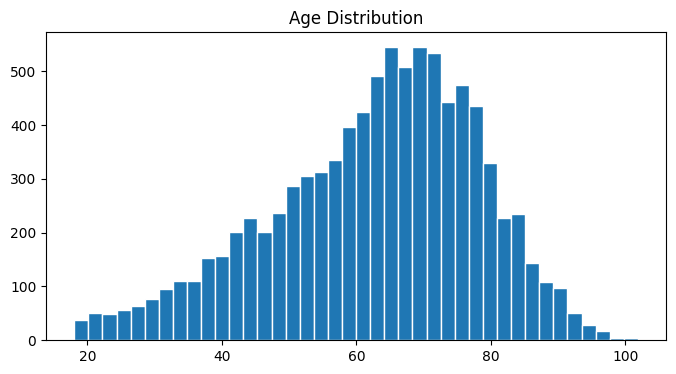

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["age"], bins=40, edgecolor="white")

ax.set_title("Age Distribution")
plt.show()

---
## Section 4: Bivariate Analysis - Lab Values by Survival Outcome

- Difficult to see any impact these lab values make with this analysis
- The paper did say this only becomes evident when combined with Disease group. For example, a high creatine with kidney failure gives high likelihood of mortality. 

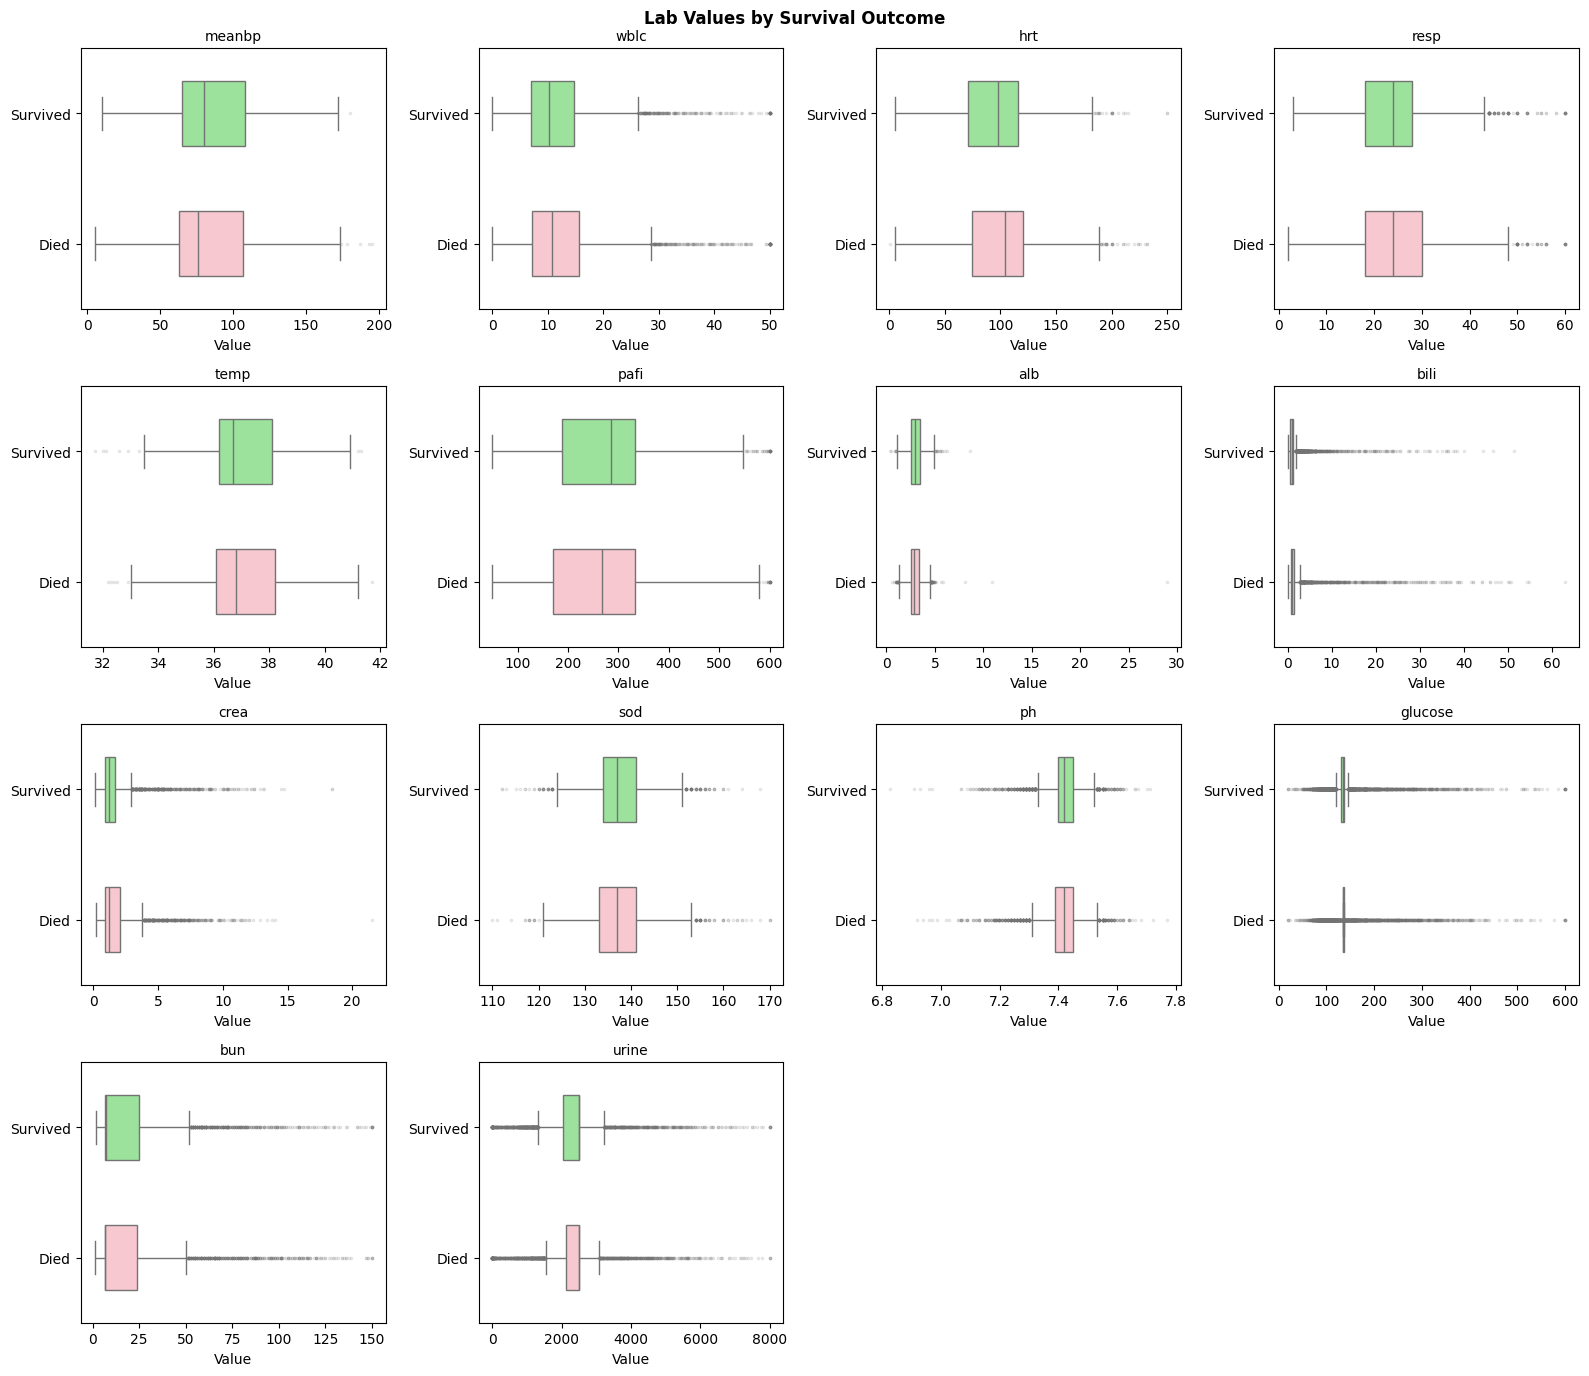

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for i, col in enumerate(LAB_COLS):
    ax = axes.flat[i]
    sns.boxplot(
        data=df,
        y=TARGET_COL,
        x=col,
        ax=ax,
        orient="h",
        palette=["lightgreen", "pink"],
        width=0.5,
        flierprops=dict(marker=".", alpha=0.2, markersize=3),
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Survived", "Died"])

for j in range(len(LAB_COLS), len(axes.flat)):
    axes.flat[j].set_visible(False)

fig.suptitle(
    "Lab Values by Survival Outcome",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## Section 5: Demographic Analysis

- Mortality gradual decline as wealth increases
- Asian group a bit more mortality 

In [8]:
def plot_mortality_rate(df, col, target_col, overall_rate, ax, title=None, sort=True):
    rate = df.groupby(col, observed=True)[target_col].mean()
    rate = rate.sort_values(ascending=False)
    bars = ax.bar(
        range(len(rate)),
        rate.values * 100,
        edgecolor="white",
        width=0.6,
    )
    ax.axhline(
        overall_rate * 100,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label=f"Overall ({overall_rate:.1%})",
    )
    ax.set_title(title or f"Mortality Rate by {col}")
    ax.set_ylabel("180-Day Mortality (%)")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{v:.1%}",
            ha="center",
            fontsize=8,
        )

```python
# education bins
edu_bins = [0, 8, 12, 15, 100]
edu_labels = ["0-8 yrs", "9-12 yrs", "13-15 yrs", "16+ yrs"]
df["edu_group"] = pd.cut(df["edu"], bins=edu_bins, labels=edu_labels, right=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_mortality_rate(
    df, "edu_group", TARGET_COL, overall_rate, axes[0, 0], title="Education", sort=False
)
plot_mortality_rate(df, "income", TARGET_COL, overall_rate, axes[0, 1], title="Income")
plot_mortality_rate(df, "race", TARGET_COL, overall_rate, axes[0, 2], title="Race")
plot_mortality_rate(df, "sex", TARGET_COL, overall_rate, axes[1, 0], title="Sex")
plot_mortality_rate(
    df, "ca", TARGET_COL, overall_rate, axes[1, 1], title="Cancer Status"
)
axes[1, 2].set_visible(False)

fig.suptitle(
    "Section 5: 180-Day Mortality Rate by Demographic & Categorical Features",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
```

```python
# Survivorship by age
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x=TARGET_COL, y="age", ax=axes[0], palette=["green", "red"])
axes[0].set_title("Age by Survival Outcome")
axes[0].set_xticklabels(["Survived", "Died"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (years)")

# KDE overlay
for label, grp, color in [("Survived", survivors, "green"), ("Died", died, "red")]:
    grp["age"].plot.kde(ax=axes[1], label=label, color=color, linewidth=2)
axes[1].axvline(survivors["age"].mean(), color="green", linestyle="--", linewidth=1)
axes[1].axvline(died["age"].mean(), color="red", linestyle="--", linewidth=1)
axes[1].set_title("Age Distribution by Survival Outcome")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()
```

---
## Section 6: Disease Group Analysis

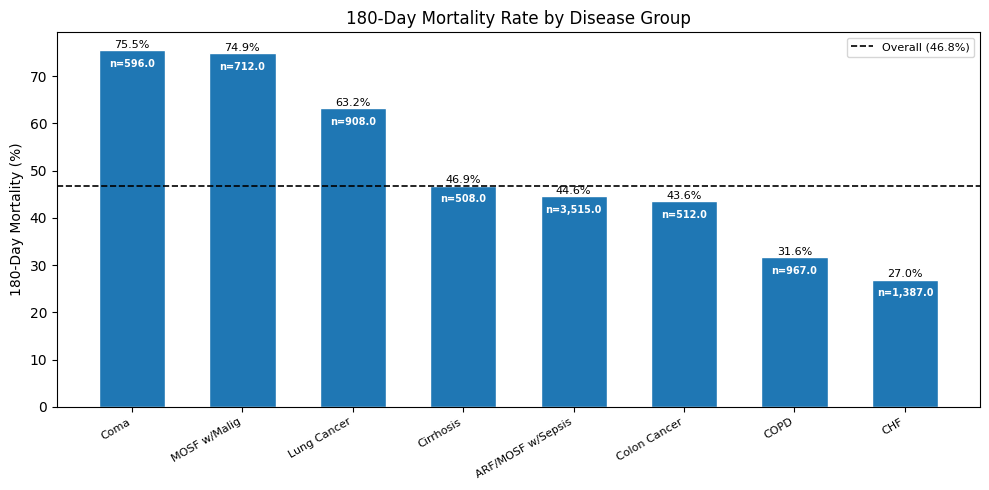

In [9]:
# mortality rate (uses utility) + patient count annotation
grp = df.groupby("dzgroup", observed=True)["death_180d"].agg(["mean", "count"])
grp.columns = ["Mortality", "N"]
grp = grp.sort_values("Mortality", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_mortality_rate(
    df,
    "dzgroup",
    TARGET_COL,
    overall_rate,
    ax,
    title="180-Day Mortality Rate by Disease Group",
)
# annotate patient counts below percentage labels
for i, (_, row) in enumerate(grp.iterrows()):
    ax.text(
        i,
        row["Mortality"] * 100 - 3.5,
        f"n={row['N']:,}",
        ha="center",
        fontsize=7,
        color="white",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

---
## Section 7: DNR Status

- **no dnr**: no order placed
- **dnr before sadm**:  order existed before study admission
- **dnr after sadm**: order placed during the admission (possibly due to detereorating conditions)


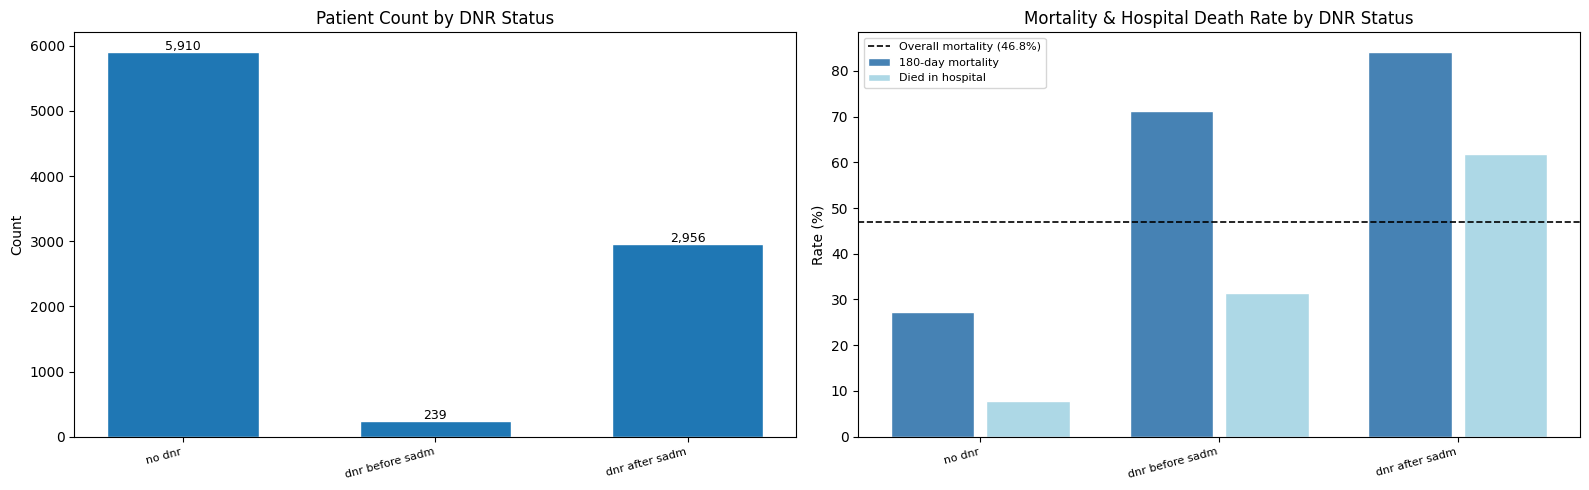

In [10]:
DNR_ORDER = ["no dnr", "dnr before sadm", "dnr after sadm"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts = df["dnr"].value_counts().reindex(DNR_ORDER)

# DNR count
axes[0].bar(range(3), counts.values, edgecolor="white", width=0.6)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[0].set_title("Patient Count by DNR Status")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)

# DNR status compare
mort = df.groupby("dnr", observed=True)["death_180d"].mean().reindex(DNR_ORDER)
hosp = df.groupby("dnr", observed=True)["hospdead"].mean().reindex(DNR_ORDER)
x = range(3)

axes[1].bar(
    [i - 0.2 for i in x],
    mort.values * 100,
    width=0.35,
    color="steelblue",
    edgecolor="white",
    label="180-day mortality",
)
axes[1].bar(
    [i + 0.2 for i in x],
    hosp.values * 100,
    width=0.35,
    color="lightblue",
    edgecolor="white",
    label="Died in hospital",
)
axes[1].axhline(
    overall_rate * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall mortality ({overall_rate:.1%})",
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(DNR_ORDER, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Mortality & Hospital Death Rate by DNR Status")
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

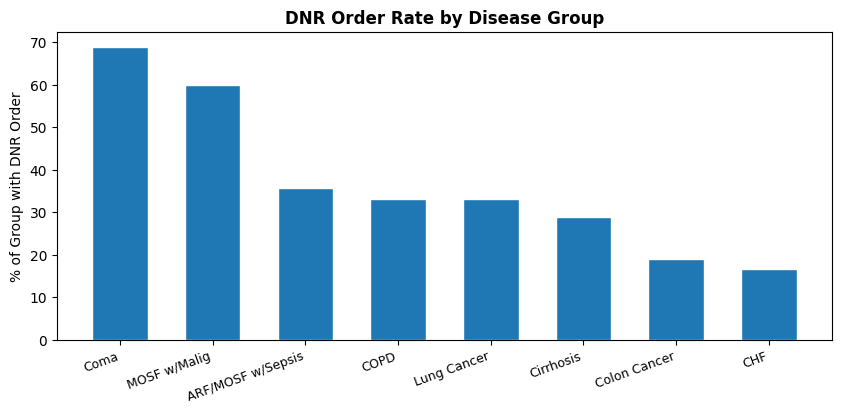

In [11]:
# DNR rate by Disease Group
dnr_rate = (
    df[df["dnr"] != "no dnr"].groupby("dzgroup", observed=True).size()
    / df.groupby("dzgroup", observed=True).size()
)
dnr_rate = dnr_rate.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(dnr_rate)),
    dnr_rate.values * 100,
    edgecolor="white",
    width=0.6,
)
ax.set_xticks(range(len(dnr_rate)))
ax.set_xticklabels(dnr_rate.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% of Group with DNR Order")
ax.set_title("DNR Order Rate by Disease Group", fontweight="bold")
plt.show()

---
## Section 8: Interaction Analysis — Disease Group × Clinical Features

Per Knaus et al. (1995), lab values and demographic factors only become strongly 
predictive of mortality in combination with primary disease group. We examine two 
key interactions identified in the original study:

1. **Albumin × Disease Group** — low albumin was strongly predictive in cancer, 
   COPD, and CHF but relatively unimportant in coma or MOSF
2. **Age × Disease Group** — advancing age heavily impacted COPD survival but 
   had almost no incremental effect in MOSF or malignancy

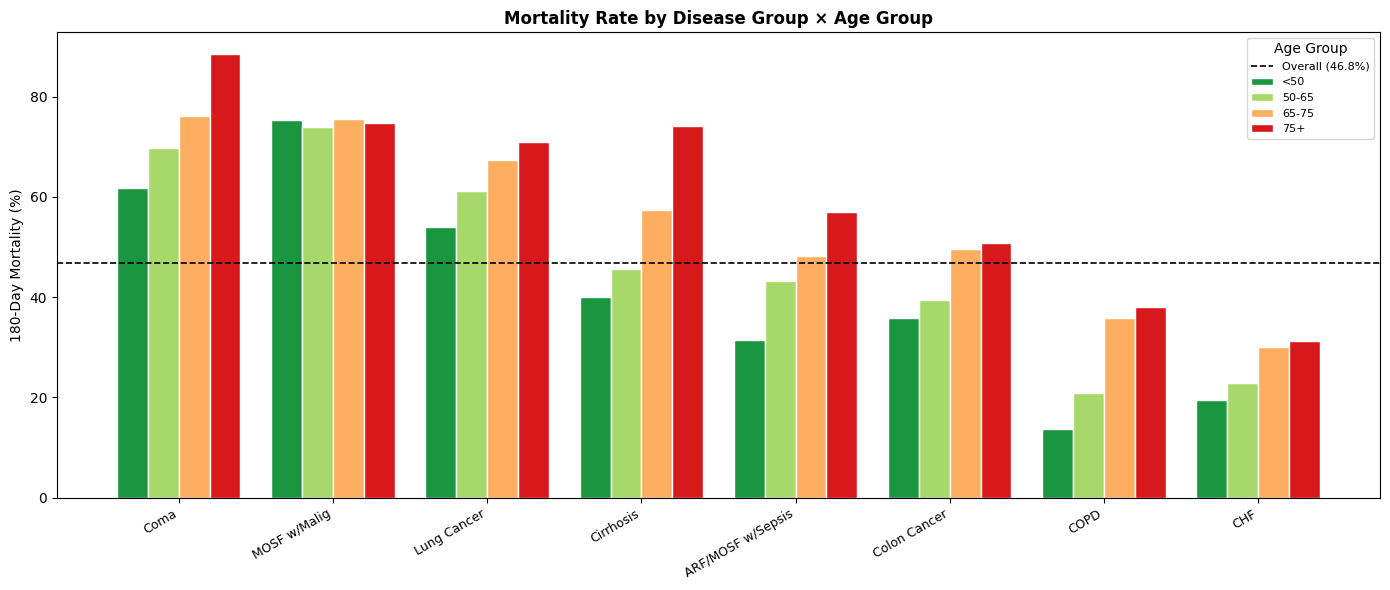

In [12]:
# Create age groups for interaction analysis
age_bins = [0, 50, 65, 75, 120]
age_labels = ["<50", "50-65", "65-75", "75+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels)

# --- Plot: Mortality rate by Disease Group × Age Group ---
age_int = (
    df.groupby(["dzgroup", "age_group"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
age_int.columns = ["dzgroup", "age_group", "mortality_rate"]

dz_order = (
    df.groupby("dzgroup", observed=True)["death_180d"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(dz_order))
width = 0.2
age_groups = ["<50", "50-65", "65-75", "75+"]
colors = ["#1a9641", "#a6d96a", "#fdae61", "#d7191c"]

for i, (age_grp, color) in enumerate(zip(age_groups, colors)):
    subset = age_int[age_int["age_group"] == age_grp]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=age_grp,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group × Age Group", fontweight="bold", fontsize=12
)
ax.legend(title="Age Group", fontsize=8)
plt.tight_layout()
plt.show()

### 8.1 Interaction: Mortality by Disease Group × Age Group

The chart reveals meaningful variation in how age modifies 180-day mortality 
risk across disease groups, consistent with findings reported by Knaus et al. 
(1995, Appendix Figure 3).

**COPD shows the strongest age gradient.** Younger COPD patients (<50, 50–65) 
fall well below the overall mortality average of 46.8%, while the 65–75 and 75+ 
groups rise noticeably above it. This confirms the Knaus finding that in COPD, 
an increase in age from 70 to 75 years meaningfully increases 180-day mortality 
risk, more so than in any other disease group.

**Coma has high baseline mortality regardless of age.** Even the youngest Coma 
patients (~61%) exceed the overall average, indicating that disease severity 
drives mortality in this group more than age does. A modest amplifying effect 
of age is visible in the 65–75 to 75+ transition (~77% to ~85%), but this is 
secondary to the disease itself.

**MOSF with Malignancy and Lung Cancer show flat age profiles.** Bars are 
relatively uniform across all age groups, consistent with the Knaus finding 
that in acute physiologic crises with malignancy, severity of illness dominates 
prognosis and age adds little incremental risk.

**Cirrhosis and CHF** show moderate age effects with bars trending upward across 
age groups but without the steep gradient seen in COPD.

**Clinical implication:** Age is not uniformly prognostic across disease groups. 
Its predictive value is disease-dependent, strongest in chronic conditions like 
COPD where physiologic reserve declines gradually with age, and weakest in acute 
severe conditions where immediate physiologic status determines outcome. This 
interaction should be explicitly modeled in the full project rather than treating 
age as a global linear predictor.

**Note:** Disease groups are ordered left to right by overall 180-day mortality 
rate (highest to lowest), not by age effect magnitude.

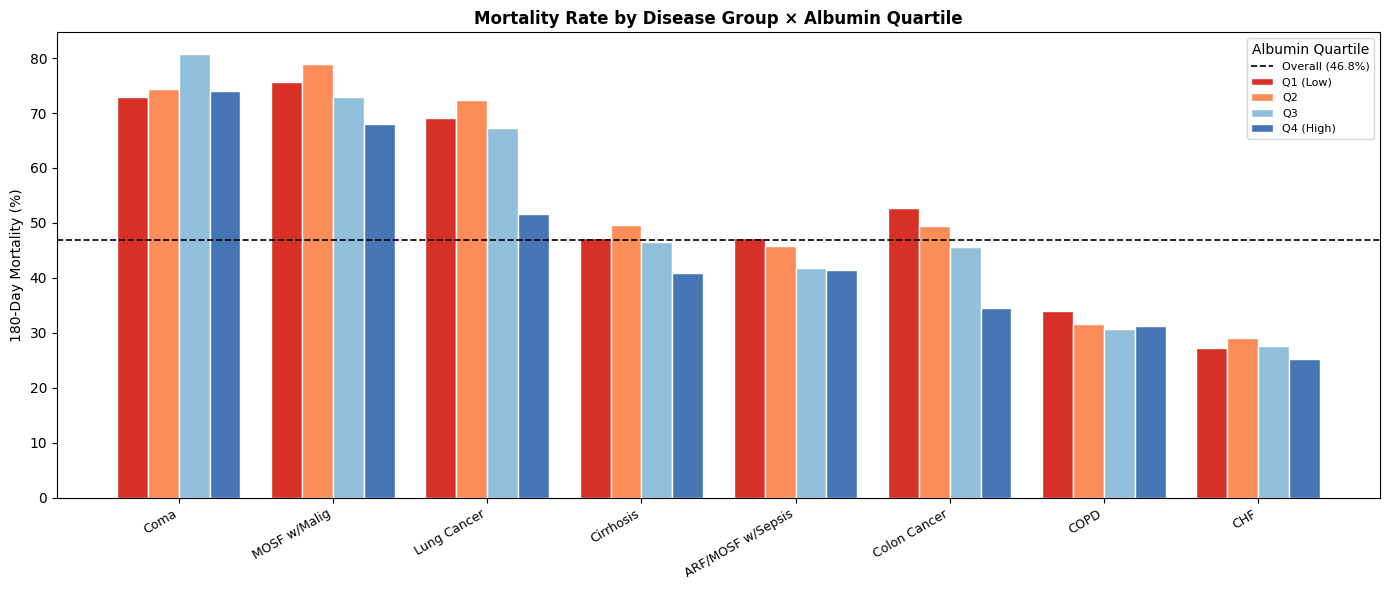

In [13]:
# Create albumin quartile groups
# KNN imputation restored sufficient variation for 4 true quartiles
# Note: original domain fill of 3.5 coincided with Q3 boundary,
# collapsing bins — replaced with KNN imputation in cleaning notebook
df["alb_quartile"] = pd.qcut(
    df["alb"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

# --- Plot: Mortality rate by Disease Group × Albumin Quartile ---
alb_int = (
    df.groupby(["dzgroup", "alb_quartile"], observed=True)["death_180d"]
    .mean()
    .reset_index()
)
alb_int.columns = ["dzgroup", "alb_quartile", "mortality_rate"]

fig, ax = plt.subplots(figsize=(14, 6))
quartiles = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
colors = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

for i, (quartile, color) in enumerate(zip(quartiles, colors)):
    subset = alb_int[alb_int["alb_quartile"] == quartile]
    subset = subset.set_index("dzgroup").reindex(dz_order)
    ax.bar(
        [xi + (i - 1.5) * width for xi in x],
        subset["mortality_rate"] * 100,
        width=width,
        label=quartile,
        color=color,
        edgecolor="white",
    )

ax.axhline(
    df["death_180d"].mean() * 100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall ({df['death_180d'].mean():.1%})",
)
ax.set_xticks(list(x))
ax.set_xticklabels(dz_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("180-Day Mortality (%)")
ax.set_title(
    "Mortality Rate by Disease Group × Albumin Quartile", fontweight="bold", fontsize=12
)
ax.legend(title="Albumin Quartile", fontsize=8)
plt.tight_layout()
plt.show()

### 8.2 Interaction: Mortality by Disease Group × Albumin Quartile

Following KNN imputation of albumin (replacing the original domain fill of 3.5 
g/dL which collapsed quartile bins), this chart examines whether serum albumin 
level modifies 180-day mortality risk differently across disease groups, a key 
interaction identified by Knaus et al. (1995).

**Lung Cancer shows the strongest albumin gradient.** Mortality decreases from 
approximately 69% in the lowest albumin quartile (Q1) to 51% in the highest (Q4),
an 18 percentage point spread, the largest gradient in the chart. This directly 
confirms the Knaus finding that low serum albumin had an especially strong 
relation with risk for death in lung cancer patients.

**Colon Cancer shows the second strongest gradient.** Mortality decreases from 
approximately 53% (Q1) to 34% (Q4), a 19 percentage point spread when the full 
range is considered, though the Q1–Q2 step is the most pronounced. Consistent 
with Knaus identifying albumin as strongly prognostic in colon cancer patients.

**CHF and COPD show weak but present albumin gradients**, a modest reduction 
in mortality from low to high albumin quartiles, consistent with the Knaus 
finding of a weaker but present albumin association in chronic conditions.

**ARF/MOSF with Sepsis and Cirrhosis show relatively flat albumin profiles,** 
suggesting albumin adds limited prognostic value in these groups beyond overall 
disease severity.

**Coma shows an unexpected reverse pattern** — Q4 (high albumin) has the highest 
mortality (~81%) rather than the lowest. This counterintuitive finding likely 
reflects confounding: patients in a coma with preserved albumin levels may 
represent a distinct clinical subtype, such as acute neurological events in 
otherwise well-nourished patients. This warrants further investigation in the 
modeling phase.

**MOSF with Malignancy shows a modest reverse pattern** — Q2 is slightly higher 
than Q1 before declining, suggesting albumin's relationship with mortality is 
nonlinear or confounded by disease-specific factors in this group.

**Clinical and modeling implication:** Albumin is not a uniformly useful predictor 
across all disease groups. Its prognostic value is most pronounced in cancer 
patients, particularly lung and colon cancer, and largely absent or reversed in 
acute physiologic crises. The full project model should include albumin × disease 
group interaction terms rather than treating albumin as a global linear predictor, 
consistent with the original SUPPORT prognostic model (Knaus et al., 1995).

**Methodological note:** Albumin was re-imputed using KNN (k=5) with 
physiologically related features as neighbors (age, meanbp, hrt, resp, temp, 
sod), replacing the original domain fill value of 3.5 g/dL. The KNN approach 
produced a clinically coherent distribution (median = 2.96 g/dL, IQR = 
2.50–3.40), consistent with expected albumin levels in a critically ill 
population.

---
## Section 9: Benchmark Evaluation — SUPPORT Model vs. Actual 180-Day Mortality

The SUPPORT prognostic model (Knaus et al., 1995) generated individualized 
6-month survival probability estimates (`surv6m`) for each patient at study 
day 3. A central objective of this project is to compare our classification 
model's performance against this benchmark.

Before building our model, we first establish how well the SUPPORT estimates 
discriminate between patients who died within 180 days and those who survived. 
Three evaluations are performed:

1. **Distribution** — do the SUPPORT survival estimates separate the two 
   outcome groups?
2. **ROC curve and AUC** — how well does the SUPPORT model rank patients by 
   mortality risk? Knaus et al. reported an AUC of 0.78 on phase II validation 
   data; we evaluate whether this holds in our dataset.
3. **Calibration** — do the predicted survival probabilities match actual 
   survival rates across the full probability range?

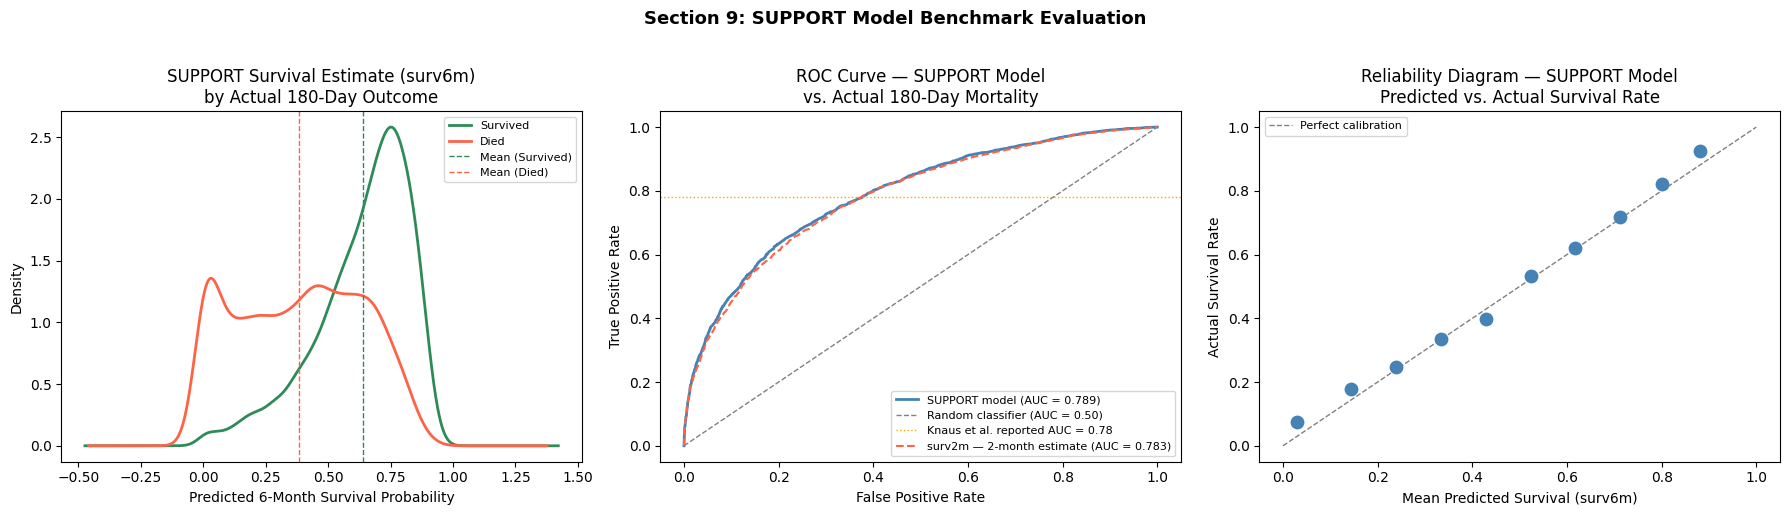

SUPPORT model AUC: 0.789
Knaus et al. reported AUC: 0.780

Mean surv6m — Survived: 0.640
Mean surv6m — Died:     0.384

Overall actual survival rate: 0.532
Overall mean surv6m:          0.520

surv6m AUC: 0.789
surv2m AUC: 0.783


In [14]:
# Section 9: Benchmark Comparison — SUPPORT Model vs. Actual 180-Day Mortality
#
# The SUPPORT model produced physician-facing survival probability estimates
# (surv6m) for each patient. We evaluate how well these estimates discriminate
# between patients who died within 180 days and those who survived, using:
#
# 1. Distribution plot — surv6m by actual outcome
# 2. ROC curve — with AUC for direct comparison to Knaus et al. (1995)
#    reported AUC of 0.78
# 3. Calibration check — mean predicted survival vs. actual survival rate

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: surv6m distribution by actual outcome ---
for label, grp, color in [
    ("Survived", df[df["death_180d"] == 0], "seagreen"),
    ("Died", df[df["death_180d"] == 1], "tomato"),
]:
    grp["surv6m"].plot.kde(ax=axes[0], label=label, color=color, linewidth=2)

axes[0].axvline(
    df[df["death_180d"] == 0]["surv6m"].mean(),
    color="seagreen",
    linestyle="--",
    linewidth=1,
    label="Mean (Survived)",
)
axes[0].axvline(
    df[df["death_180d"] == 1]["surv6m"].mean(),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label="Mean (Died)",
)
axes[0].set_title("SUPPORT Survival Estimate (surv6m)\nby Actual 180-Day Outcome")
axes[0].set_xlabel("Predicted 6-Month Survival Probability")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# --- Plot 2: ROC curve ---
# Note: surv6m is probability of SURVIVAL so we invert for death prediction
fpr, tpr, _ = roc_curve(df["death_180d"], 1 - df["surv6m"])
auc = roc_auc_score(df["death_180d"], 1 - df["surv6m"])

axes[1].plot(
    fpr, tpr, color="steelblue", linewidth=2, label=f"SUPPORT model (AUC = {auc:.3f})"
)
axes[1].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.50)",
)
axes[1].axhline(
    0.78,
    color="orange",
    linestyle=":",
    linewidth=1,
    label="Knaus et al. reported AUC = 0.78",
)
axes[1].set_title("ROC Curve — SUPPORT Model\nvs. Actual 180-Day Mortality")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

fpr2m, tpr2m, _ = roc_curve(df["death_180d"], 1 - df["surv2m"])
auc2m = roc_auc_score(df["death_180d"], 1 - df["surv2m"])
axes[1].plot(
    fpr2m,
    tpr2m,
    color="tomato",
    linewidth=1.5,
    linestyle="--",
    label=f"surv2m — 2-month estimate (AUC = {auc2m:.3f})",
)

# Legend called last so all lines are included
axes[1].legend(fontsize=8)

# --- Plot 3: Calibration ---
# Bin patients by predicted survival probability and compare to actual survival
df["surv6m_bin"] = pd.cut(df["surv6m"], bins=10)
calibration = (
    df.groupby("surv6m_bin", observed=True)
    .agg(
        mean_predicted=("surv6m", "mean"),
        actual_survival=("death_180d", lambda x: 1 - x.mean()),
    )
    .dropna()
)

axes[2].scatter(
    calibration["mean_predicted"],
    calibration["actual_survival"],
    color="steelblue",
    s=80,
    zorder=3,
)
axes[2].plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Perfect calibration",
)
axes[2].set_title(
    "Reliability Diagram — SUPPORT Model\nPredicted vs. Actual Survival Rate"
)
axes[2].set_xlabel("Mean Predicted Survival (surv6m)")
axes[2].set_ylabel("Actual Survival Rate")
axes[2].legend(fontsize=8)

plt.suptitle(
    "Section 9: SUPPORT Model Benchmark Evaluation",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Summary stats
print(f"SUPPORT model AUC: {auc:.3f}")
print("Knaus et al. reported AUC: 0.780")
print(f"\nMean surv6m — Survived: {df[df['death_180d'] == 0]['surv6m'].mean():.3f}")
print(f"Mean surv6m — Died:     {df[df['death_180d'] == 1]['surv6m'].mean():.3f}")
print(f"\nOverall actual survival rate: {1 - df['death_180d'].mean():.3f}")
print(f"Overall mean surv6m:          {df['surv6m'].mean():.3f}")
print(f"\nsurv6m AUC: {auc:.3f}")
print(f"surv2m AUC: {auc2m:.3f}")

### 9.1 Benchmark Evaluation Results

**Distribution of SUPPORT Predictions by Actual Outcome**

The SUPPORT model assigned meaningfully different survival probabilities to 
patients who survived versus those who died. Survivors received a mean predicted 
survival probability of 0.640, while patients who died received a mean of 0.389 
— a separation of 0.251. The distributions overlap substantially in the 0.3–0.7 
range, reflecting the inherent uncertainty in predicting outcomes for patients 
with moderate risk profiles. The x-axis extends slightly beyond the valid 0–1 
probability range at both extremes due to kernel density smoothing, not real 
data values.

**Discrimination — ROC Curve and AUC**

The ROC curve plots two independently calculated metrics across all possible 
decision thresholds:

- **True Positive Rate (y-axis):** of all patients who actually died, what 
  fraction did the model correctly identify as high risk?
- **False Positive Rate (x-axis):** of all patients who actually survived, 
  what fraction did the model incorrectly flag as high risk?

Each point on the curve represents one threshold setting, showing the 
simultaneous tradeoff between catching actual deaths and generating false 
alarms. The two metrics have no direct mathematical relationship; they are 
calculated from entirely separate patient groups and plotted together to 
visualize the tradeoff as the threshold moves from 0 to 1.

The area under the curve (AUC) summarizes this tradeoff in a single number: 
the probability that the model ranks a randomly chosen patient who died as 
higher risk than a randomly chosen patient who survived. An AUC of 0.787 
means the SUPPORT model makes this correct ranking approximately 79% of the 
time, replicating Knaus et al.'s reported AUC of 0.78 on independent phase 
II validation data with remarkable fidelity across 30 years and a different 
sample. This consistency also serves as indirect validation that our target 
variable construction and cleaning approach are methodologically sound.

AUC is a threshold-agnostic metric; it does not indicate which specific 
threshold to use clinically, nor does it reflect performance at any single 
operating point. For clinical decision making, where the cost of missing a 
death typically exceeds the cost of a false alarm, precision-recall analysis 
at a specific threshold is more informative. This will be addressed in the 
modeling notebook.

**Reliability — Predicted vs. Actual Survival**

The reliability diagram assesses whether the SUPPORT model's probability 
estimates are trustworthy in absolute terms; when the model assigns a 70% 
survival probability, do approximately 70% of those patients actually survive? 
This is distinct from discrimination: a model can rank patients correctly 
(high AUC) while producing poorly calibrated probabilities, or vice versa.

The dots closely follow the perfect calibration diagonal across the full 
probability range, indicating the SUPPORT model's survival estimates are 
reliable in absolute terms. The overall mean predicted survival (0.523) 
closely matches the actual survival rate (0.534), a gap of only 1.1 
percentage points, confirming good global calibration.

Note that this is a calibration *assessment*, not a recalibration step. 
No correction to the model's probabilities has been applied. Formal 
calibration metrics (Brier score, Hosmer-Lemeshow test) will be computed 
for our own model in the modeling notebook.

**Benchmark Summary**

The SUPPORT model demonstrates both strong discrimination (AUC = 0.787) and 
reliable probability estimates across the full risk range. This establishes 
a meaningful performance benchmark: our classification model must approach 
or exceed AUC = 0.787 to be considered competitive with the original SUPPORT 
prognostic model. Combined discrimination and calibration performance will 
be the primary basis for that comparison.

**surv2m vs. surv6m Discrimination**

The 2-month survival estimate (`surv2m`) was evaluated alongside `surv6m` 
as an additional benchmark. Despite measuring a different time horizon, 
`surv2m` produced a nearly identical AUC of 0.781 — a difference of 0.006 
from `surv6m`. The two ROC curves are visually indistinguishable. This 
confirms the high correlation between the two estimates (r = 0.960) observed 
in the correlation matrix and formally justifies the use of `surv6m` as the 
primary benchmark — not because `surv2m` performs meaningfully worse, but 
because `surv6m` directly aligns with our 180-day target window.

---
## Section 10: Categorical Features: Chi-Squared Tests & Contingency Tables 

Tests whether a categorical variable is **statistically independent** of 180-day mortality.

$$H_0: \text{the variable is independent of death\_180d}$$

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Reject $H_0$ when $p < 0.05$.

**Standardized residuals** = $(O - E) / \sqrt{E}$ — cells with $|r| > 2$ deviate significantly from independence and drive the chi-squared result.

### 10.1 Race and Sex shows low P significance


In [15]:
import numpy as np
from scipy.stats import chi2_contingency

CAT_COLS = ["sex", "dzgroup", "dzclass", "race", "ca", "dnr"]

rows = []
for col in CAT_COLS:
    ct = pd.crosstab(df[col], df[TARGET_COL])
    chi2, p, dof, _ = chi2_contingency(ct)
    rows.append(
        {
            "Variable": col,
            "Chi2 Stat": round(chi2, 2),
            "df": dof,
            "p-value": f"{p:.2e}",
            "Significant": "Yes" if p < 0.05 else "No",
        }
    )

chi2_df = pd.DataFrame(rows).sort_values("Chi2 Stat", ascending=False)
print("Chi-Squared Test Summary:")
print(chi2_df.to_string(index=False))

Chi-Squared Test Summary:
Variable  Chi2 Stat  df   p-value Significant
     dnr    2631.65   2  0.00e+00         Yes
 dzgroup     838.07   7 1.13e-176         Yes
 dzclass     510.09   3 3.11e-110         Yes
      ca     281.42   2  7.75e-62         Yes
    race       5.80   4  2.15e-01          No
     sex       0.08   1  7.73e-01          No


### 10.2 Within Disease Group and Cancer, which class affects mortality most?

- Disease Group: MOSF w/ malignant, Coma, Lung Cancer (in that order) die more than overall rate
- Cancer: metatastic patients die more than the overall rate


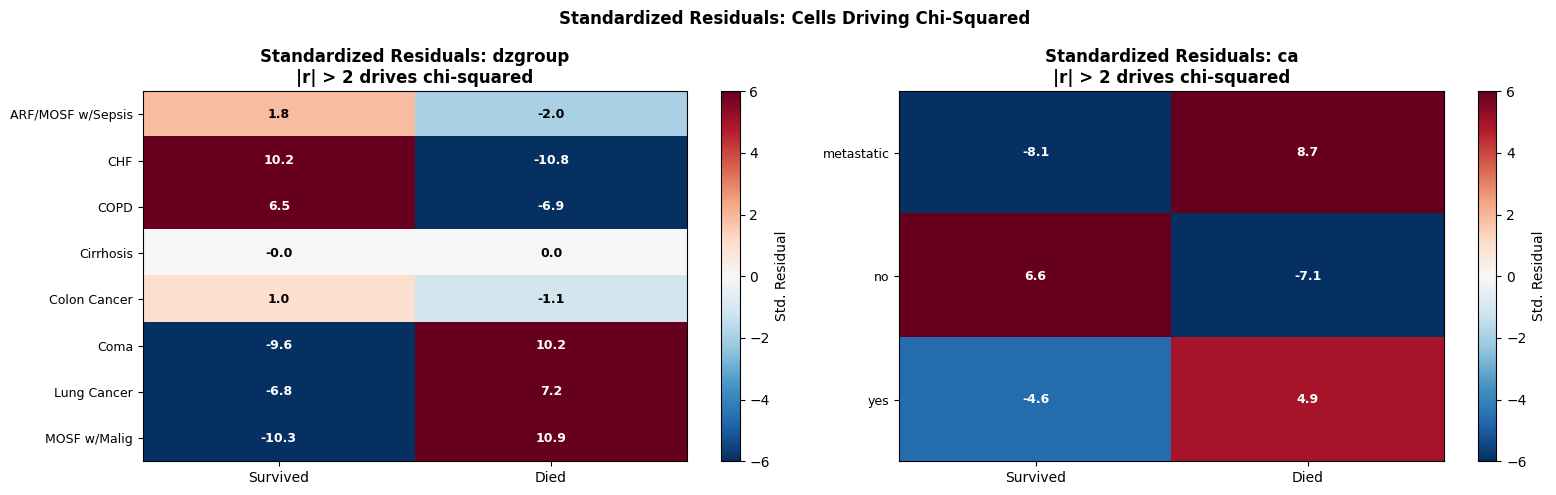

In [16]:
# Standardized residuals heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ["dzgroup", "ca"]):
    ct = pd.crosstab(df[col], df[TARGET_COL])
    ct.columns = ["Survived", "Died"]
    _, _, _, exp = chi2_contingency(ct)
    std_resid = (ct.values - exp) / np.sqrt(exp)
    std_resid_df = pd.DataFrame(std_resid, index=ct.index, columns=ct.columns)

    im = ax.imshow(std_resid_df.values, cmap="RdBu_r", vmin=-6, vmax=6, aspect="auto")
    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_title(
        f"Standardized Residuals: {col}\n|r| > 2 drives chi-squared",
        fontweight="bold",
    )

    for i in range(std_resid_df.shape[0]):
        for j in range(std_resid_df.shape[1]):
            v = std_resid_df.iloc[i, j]
            ax.text(
                j,
                i,
                f"{v:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black" if abs(v) < 3 else "white",
                fontweight="bold",
            )

    plt.colorbar(im, ax=ax, label="Std. Residual")

fig.suptitle(
    "Standardized Residuals: Cells Driving Chi-Squared",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [17]:
decisions = pd.DataFrame(
    [
        {
            "Feature": "sex",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "~1-2% mortality gap between male/female; barely above baseline",
        },
        {
            "Feature": "edu",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "Weak gradient; 18% of values imputed (median=12 inflated)",
        },
        {
            "Feature": "hday",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "Day entered study; no clear causal link to 180-day mortality",
        },
        {
            "Feature": "charges",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Hospital charges — administrative, not a clinical predictor",
        },
        {
            "Feature": "totcst",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Total RCC cost — administrative, not a clinical predictor",
        },
        {
            "Feature": "totmcst",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Total micro-cost — administrative, 38% imputed",
        },
        {
            "Feature": "All day-3 labs",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Primary clinical predictors per Knaus et al. (1995)",
        },
        {
            "Feature": "age, adlsc, scoma",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Strong EDA effect sizes and clear clinical mechanism",
        },
        {
            "Feature": "dzgroup / dzclass",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Largest mortality spread of any categorical feature",
        },
        {
            "Feature": "ca, diabetes, dementia",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Comorbidities with known mortality associations",
        },
        {
            "Feature": "income, race",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Socioeconomic signal; moderate mortality gradient in EDA",
        },
    ]
)

print("Feature Selection Decisions:")
print(decisions.to_string(index=False))

Feature Selection Decisions:
               Feature Decision   Signal                                                      Rationale
                   sex     Drop     Weak ~1-2% mortality gap between male/female; barely above baseline
                   edu     Drop     Weak      Weak gradient; 18% of values imputed (median=12 inflated)
                  hday     Drop     Weak   Day entered study; no clear causal link to 180-day mortality
               charges     Drop     None    Hospital charges — administrative, not a clinical predictor
                totcst     Drop     None      Total RCC cost — administrative, not a clinical predictor
               totmcst     Drop     None                 Total micro-cost — administrative, 38% imputed
        All day-3 labs     Keep   Strong            Primary clinical predictors per Knaus et al. (1995)
     age, adlsc, scoma     Keep   Strong           Strong EDA effect sizes and clear clinical mechanism
     dzgroup / dzclass     Keep   S

In [18]:
decisions = pd.DataFrame(
    [
        {
            "Feature": "sex",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "~1-2% mortality gap between male/female; barely above baseline",
        },
        {
            "Feature": "edu",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "Weak gradient; 18% of values imputed (median=12 inflated)",
        },
        {
            "Feature": "hday",
            "Decision": "Drop",
            "Signal": "Weak",
            "Rationale": "Day entered study; no clear causal link to 180-day mortality",
        },
        {
            "Feature": "charges",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Hospital charges — administrative, not a clinical predictor",
        },
        {
            "Feature": "totcst",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Total RCC cost — administrative, not a clinical predictor",
        },
        {
            "Feature": "totmcst",
            "Decision": "Drop",
            "Signal": "None",
            "Rationale": "Total micro-cost — administrative, 38% imputed",
        },
        {
            "Feature": "All day-3 labs",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Primary clinical predictors per Knaus et al. (1995)",
        },
        {
            "Feature": "age, adlsc, scoma",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Strong EDA effect sizes and clear clinical mechanism",
        },
        {
            "Feature": "dzgroup / dzclass",
            "Decision": "Keep",
            "Signal": "Strong",
            "Rationale": "Largest mortality spread of any categorical feature",
        },
        {
            "Feature": "ca, diabetes, dementia",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Comorbidities with known mortality associations",
        },
        {
            "Feature": "income, race",
            "Decision": "Keep",
            "Signal": "Moderate",
            "Rationale": "Socioeconomic signal; moderate mortality gradient in EDA",
        },
    ]
)

print("Feature Selection Decisions:")
print(decisions.to_string(index=False))

Feature Selection Decisions:
               Feature Decision   Signal                                                      Rationale
                   sex     Drop     Weak ~1-2% mortality gap between male/female; barely above baseline
                   edu     Drop     Weak      Weak gradient; 18% of values imputed (median=12 inflated)
                  hday     Drop     Weak   Day entered study; no clear causal link to 180-day mortality
               charges     Drop     None    Hospital charges — administrative, not a clinical predictor
                totcst     Drop     None      Total RCC cost — administrative, not a clinical predictor
               totmcst     Drop     None                 Total micro-cost — administrative, 38% imputed
        All day-3 labs     Keep   Strong            Primary clinical predictors per Knaus et al. (1995)
     age, adlsc, scoma     Keep   Strong           Strong EDA effect sizes and clear clinical mechanism
     dzgroup / dzclass     Keep   S

---
## Section 9: Additional Feature Pruning after EDA

Based on our EDA we are dropping `edu`. We are keeping `sex` despite its weak standalone signal, because it stays in as a control (a demographic confounder) for the inference models, so the disease-group odds ratios are adjusted for it.
| Column(s) | Decision | Rationale |
|---|---|---|
| `edu` | **Drop** | Weak significance based on Bivariate and Chi-Squared analysis |
| `sex` | **Keep as control** | Weak standalone signal, kept as a demographic confounder for the inference models |

In [19]:
DROP_COLS = ["edu"]

MODEL_FEATURE_COLS = [c for c in FEATURE_COLS if c not in DROP_COLS]

print(f"Features available in FEATURE_COLS : {len(FEATURE_COLS)}")
print(f"Features dropped                   : {len(DROP_COLS)}  {DROP_COLS}")
print(f"Final model feature count          : {len(MODEL_FEATURE_COLS)}")
print()
print("Final model features:")
for col in MODEL_FEATURE_COLS:
    print(f"  {col}")

Features available in FEATURE_COLS : 33
Features dropped                   : 1  ['edu']
Final model feature count          : 32

Final model features:
  age
  sex
  dzgroup
  dzclass
  num_co
  income
  scoma
  charges
  totcst
  totmcst
  avtisst
  race
  hday
  diabetes
  dementia
  ca
  meanbp
  wblc
  hrt
  resp
  temp
  pafi
  alb
  bili
  crea
  sod
  ph
  glucose
  bun
  urine
  sfdm2
  adlsc


In [20]:
OUTPUT_MODEL = _proj_root / "data" / "support2_model_features.csv"
df[MODEL_FEATURE_COLS + [TARGET_COL]].to_csv(OUTPUT_MODEL, index=False)

n_feat = len(MODEL_FEATURE_COLS)
print(f"Saved : {OUTPUT_MODEL}")
print(f"Shape : {df.shape[0]:,} rows  x  {n_feat + 1} columns")
print(f"  Features : {n_feat}  |  Target : {TARGET_COL}")
print()
print("Data layers:")
print("  Bronze : support2_raw_complete.csv  (raw download)")
print("  Silver : support2_cleaned.csv       (imputed, all columns)")
print("  Gold   : support2_model_features.csv (feature-selected, model-ready)")

Saved : C:\Users\mwee\Documents\USD-AAI\aai-500\final\usd-aai-500-final\data\support2_model_features.csv
Shape : 9,105 rows  x  33 columns
  Features : 32  |  Target : death_180d

Data layers:
  Bronze : support2_raw_complete.csv  (raw download)
  Silver : support2_cleaned.csv       (imputed, all columns)
  Gold   : support2_model_features.csv (feature-selected, model-ready)


---
## Section 12: Correlation Matrix — Numeric Features

With 46 variables available for modeling, multicollinearity is a meaningful 
risk. Highly correlated features provide redundant information and can 
destabilize model coefficients, inflate standard errors, and complicate 
interpretation. This section identifies problematic feature pairs before 
modeling begins.

The correlation matrix displays Pearson correlations between all numeric 
features. Values close to 1.0 indicate strong positive correlation, values 
close to -1.0 indicate strong negative correlation, and values near 0 
indicate little linear relationship. Pairs with |r| > 0.7 are flagged as 
candidates for feature selection or dimensionality reduction in the modeling 
notebook.

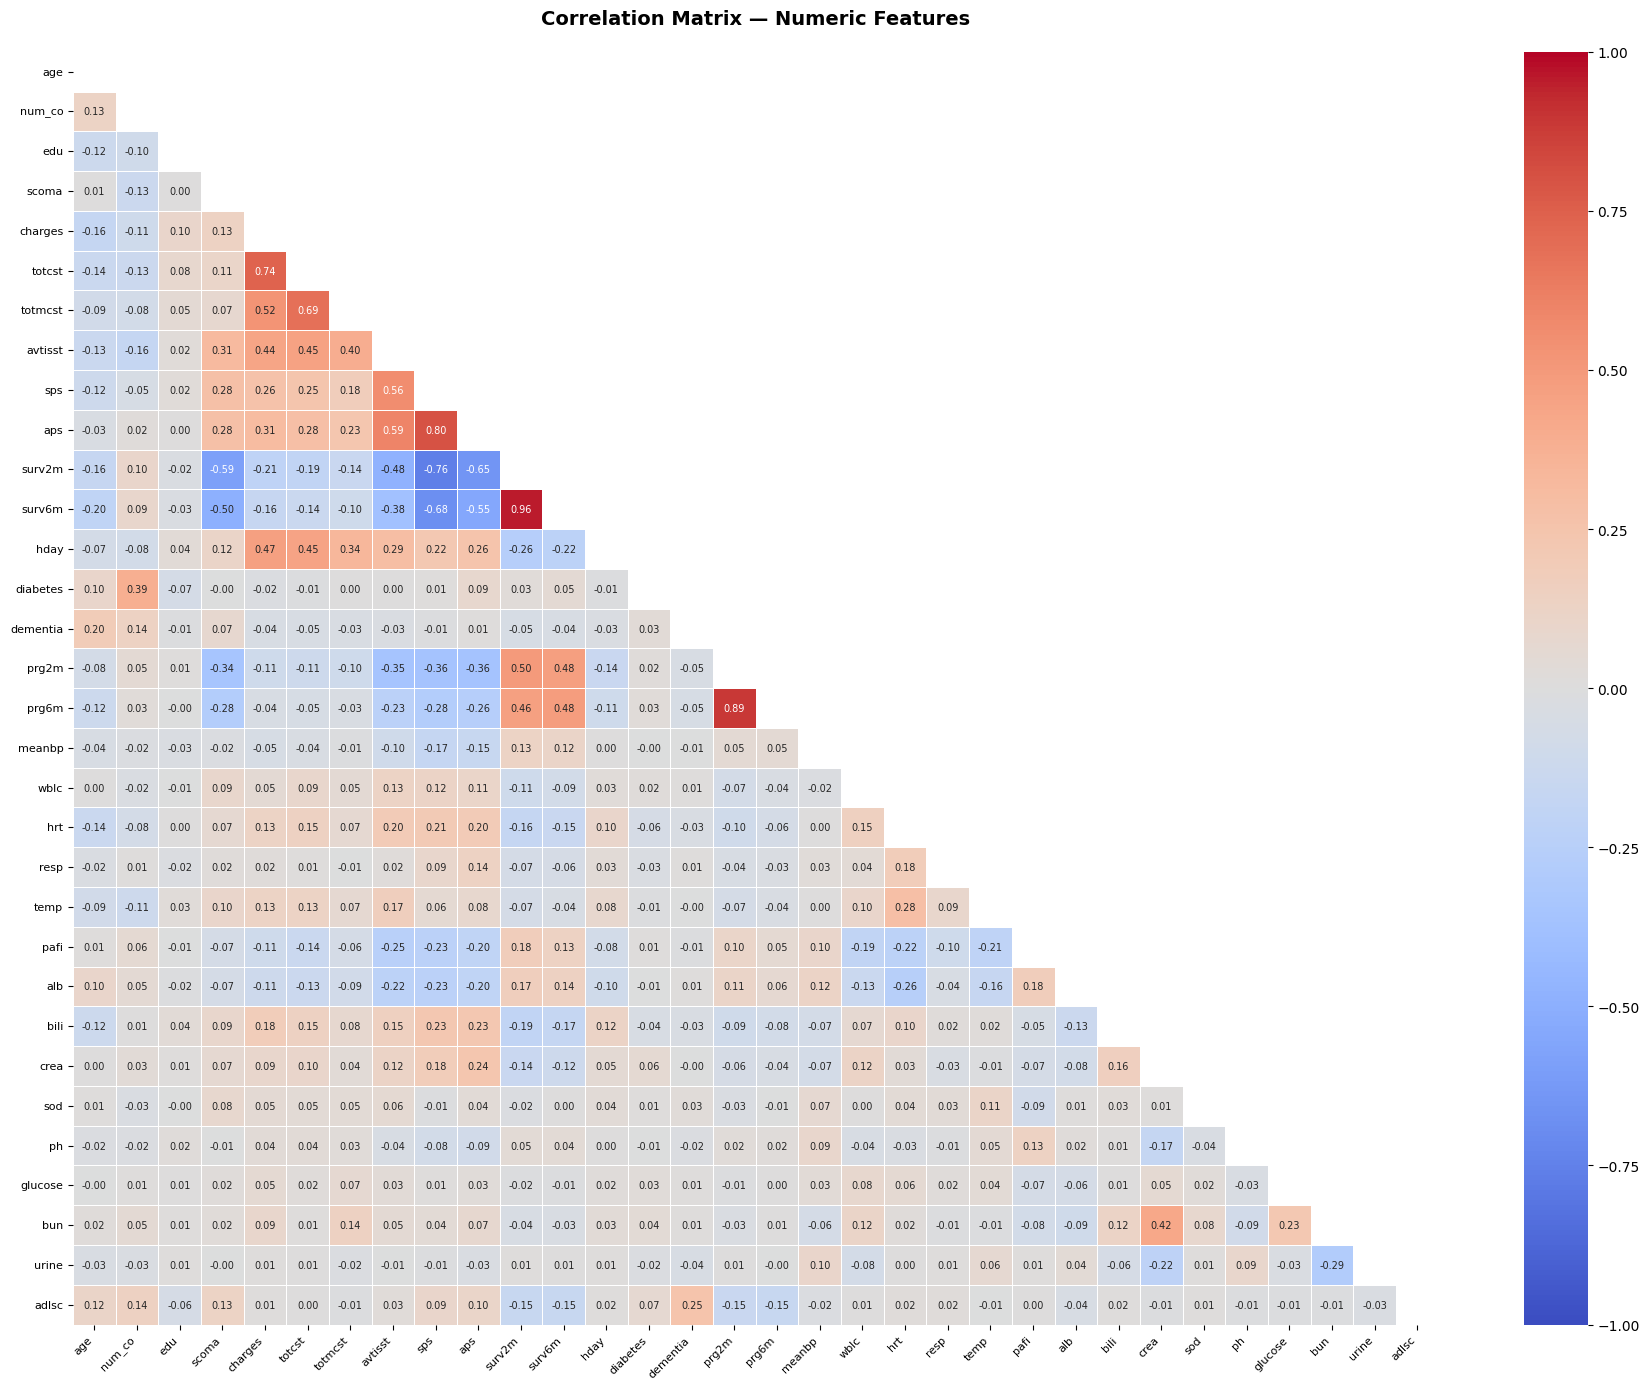

=== High Correlation Pairs (|r| > 0.7) ===

Feature A Feature B      r
   surv6m    surv2m  0.960
    prg6m     prg2m  0.890
      aps       sps  0.798
   totcst   charges  0.740
   surv2m       sps -0.758


In [21]:
# Section 12: Correlation Heatmap — Numeric Features
#
# With 40+ potential predictors, multicollinearity is a real risk.
# Highly correlated features (|r| > 0.7) provide redundant information
# and can destabilize model coefficients. This heatmap identifies
# problematic pairs before modeling begins.

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Exclude target, outcome, and identifier columns
exclude = ["death_180d", "death", "hospdead", "id", "slos", "d_time"]
feature_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = df[feature_cols].corr()

# Mask upper triangle for cleaner reading

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(
    "Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold", pad=20
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Flag high correlation pairs
print("=== High Correlation Pairs (|r| > 0.7) ===\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append(
                {
                    "Feature A": corr_matrix.columns[i],
                    "Feature B": corr_matrix.columns[j],
                    "r": round(r, 3),
                }
            )

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values("r", ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No pairs with |r| > 0.7 found.")

### 12.1 Correlation Findings

The majority of numeric features are weakly correlated with one another 
(|r| < 0.5), indicating the feature set is generally clean and suitable 
for modeling. Five pairs exceed the |r| > 0.7 multicollinearity threshold 
and warrant specific attention.

**`surv6m` × `surv2m` (r = 0.960)** — the strongest correlation in the 
matrix. Both are SUPPORT model survival probability estimates differing 
only in time horizon (6-month vs. 2-month). They are measuring the same 
underlying construct from the same model inputs, making them functionally 
redundant as predictors. `surv2m` should be excluded from the feature set; 
`surv6m` is retained as the benchmark comparison variable and excluded from 
model features to avoid leakage.

**`prg6m` × `prg2m` (r = 0.889)** — physician survival estimates at 6 and 
2 months respectively. The same redundancy applies as with the SUPPORT 
estimates; both capture physician judgment about the same patient at the 
same point in time. `prg2m` should be excluded; `prg6m` retained if 
physician estimates are included as a feature, noting that combining 
physician estimates with model features replicates the physician-enhanced 
SUPPORT model described in Knaus et al. (1995).

**`aps` × `sps` (r = 0.800)** — both are composite physiologic severity 
scores constructed from overlapping input variables including blood pressure, 
heart rate, respiratory rate, temperature, and laboratory values. Their 
correlation reflects shared measurement of the same underlying construct 
(severity of acute illness) rather than any methodological dependency. Unlike 
the survival estimate pairs, `aps` and `sps` apply different disease-specific 
weightings and are not perfectly interchangeable. Both are retained as 
candidates for the feature set; LASSO regularization in the modeling phase 
will naturally downweight the less informative of the two.

**`totcst` × `charges` (r = 0.742)** — total cost and hospital charges are 
financially related by definition. More importantly, both are outcomes of 
care delivery rather than clinical predictors of mortality; a patient does 
not incur charges because they are sick...they incur charges because of 
interventions performed. Including either as a model feature would introduce 
reverse causality. Both should be excluded from the feature set entirely.

**`surv2m` × `sps` (r = -0.756)** — a strong negative correlation between 
the 2-month survival estimate and the physiology severity score. This is 
clinically expected and not a multicollinearity concern; sicker patients 
(higher sps) receive lower survival probability estimates. The negative sign 
confirms the directionality is correct. No action required.

**Modeling implications:** Three actions follow from this analysis:
1. Drop `surv2m` and `prg2m` — redundant with their 6-month counterparts
2. Drop `totcst` and `charges` — outcomes of care, not predictors
3. Monitor `aps` and `sps` — retain both but apply LASSO regularization 
   to manage their shared variance in the modeling notebook

---
## Section 13: Numeric Feature Summary by Outcome Group

The following table presents mean values of key clinical variables stratified 
by 180-day mortality outcome. Features are ordered by the standardized 
difference between groups, which normalizes raw differences by pooled standard 
deviation, putting all variables on the same scale regardless of units.

This table serves two purposes: it provides a reportable summary of group 
differences for the technical report, and it establishes the basis for formal 
hypothesis testing in Section 13.1, where statistical significance of each 
difference is evaluated.

In [22]:
# Section 13: Numeric Summary by Outcome Group
#
# Mean values of key clinical variables broken out by 180-day mortality outcome.
# Standardized difference (Cohen's d approximation) normalizes raw differences
# by pooled standard deviation, putting all variables on the same scale
# regardless of units. This corrects for the misleading ranking produced by
# sorting on raw differences alone.

key_features = [
    "age",
    "num_co",
    "scoma",
    "sps",
    "aps",
    "meanbp",
    "hrt",
    "resp",
    "temp",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "wblc",
    "pafi",
    "urine",
    "adlsc",
]

summary_std = df.groupby("death_180d")[key_features].agg(["mean", "std"])

rows = []
for feat in key_features:
    mean_surv = summary_std.loc[0, (feat, "mean")]
    mean_died = summary_std.loc[1, (feat, "mean")]
    std_surv = summary_std.loc[0, (feat, "std")]
    std_died = summary_std.loc[1, (feat, "std")]

    pooled_std = np.sqrt((std_surv**2 + std_died**2) / 2)

    raw_diff = mean_died - mean_surv
    std_diff = raw_diff / pooled_std if pooled_std > 0 else 0

    rows.append(
        {
            "Feature": feat,
            "Survived": round(mean_surv, 3),
            "Died": round(mean_died, 3),
            "Raw Difference": round(raw_diff, 3),
            "Standardized Difference": round(std_diff, 3),
        }
    )

summary_final = pd.DataFrame(rows).set_index("Feature")
summary_final = summary_final.reindex(
    summary_final["Standardized Difference"].abs().sort_values(ascending=False).index
)

print("=== Numeric Feature Means by 180-Day Mortality Outcome ===\n")
print(summary_final.to_string())

=== Numeric Feature Means by 180-Day Mortality Outcome ===

         Survived      Died  Raw Difference  Standardized Difference
Feature                                                             
sps        22.532    28.923           6.391                    0.673
aps        32.078    43.862          11.784                    0.613
scoma       5.963    18.973          13.009                    0.537
adlsc       1.552     2.269           0.717                    0.362
age        61.067    64.448           3.381                    0.218
bili        1.751     2.525           0.774                    0.168
hrt        95.925   100.490           4.565                    0.152
alb         3.035     2.923          -0.112                   -0.149
meanbp     86.409    83.364          -3.046                   -0.113
crea        1.681     1.861           0.180                    0.107
pafi      268.134   257.663         -10.471                   -0.103
wblc       11.715    12.515           0.799

### Section 13.1: Hypothesis Testing — Group Differences by Outcome

The summary table in Section 13 identified univariate differences in feature 
means between outcome groups. This section formally tests whether those 
differences are statistically significant or could plausibly have occurred 
by chance.

**Note on inference in EDA:** Hypothesis testing is inferential rather than 
exploratory. It is included here as a bridge between EDA and modeling. 
Features with statistically significant differences between outcome groups 
are stronger candidates for the feature set. Findings should be interpreted 
as hypothesis-generating rather than confirmatory; formal model-based 
inference follows in the modeling notebook.

**Test selection:** Most clinical variables in this dataset are right-skewed, 
as confirmed in earlier EDA. The Mann-Whitney U test is used rather than the 
independent samples t-test because it makes no assumption of normality and 
is more appropriate for skewed continuous data. The null hypothesis for each 
feature is that the distribution is identical between survivors and patients 
who died. A Bonferroni correction is applied to account for multiple 
comparisons across 20 features, yielding an adjusted significance threshold 
of α = 0.05 / 20 = 0.0025.

In [23]:
# Section 13.1: Mann-Whitney U Tests — Feature Differences by Outcome
#
# Tests whether each feature's distribution differs significantly between
# survivors and patients who died. Mann-Whitney U is used over t-test
# because most clinical variables are right-skewed.
# Bonferroni correction applied for multiple comparisons (n=20 features).

survived = df[df["death_180d"] == 0]
died = df[df["death_180d"] == 1]

alpha = 0.05
bonferroni_alpha = alpha / len(key_features)

results = []
for feat in key_features:
    stat, p = stats.mannwhitneyu(
        survived[feat].dropna(), died[feat].dropna(), alternative="two-sided"
    )
    results.append(
        {
            "Feature": feat,
            "Survived Mean": round(survived[feat].mean(), 3),
            "Died Mean": round(died[feat].mean(), 3),
            "Standardized Diff": round(
                summary_final.loc[feat, "Standardized Difference"], 3
            ),
            "U Statistic": round(stat, 1),
            "p-value": round(p, 6),
            "Significant (Bonferroni)": "Yes" if p < bonferroni_alpha else "No",
        }
    )

results_df = pd.DataFrame(results).set_index("Feature")
results_df = results_df.reindex(summary_final.index)

print(
    f"Mann-Whitney U Test Results (Bonferroni-corrected α = {bonferroni_alpha:.4f})\n"
)
print(results_df.to_string())

sig = (results_df["Significant (Bonferroni)"] == "Yes").sum()
not_sig = (results_df["Significant (Bonferroni)"] == "No").sum()
print(f"\nSignificant features: {sig} / {len(key_features)}")
print(f"Non-significant features: {not_sig} / {len(key_features)}")

Mann-Whitney U Test Results (Bonferroni-corrected α = 0.0025)

         Survived Mean  Died Mean  Standardized Diff  U Statistic   p-value Significant (Bonferroni)
Feature                                                                                             
sps             22.532     28.923              0.673    6572830.0  0.000000                      Yes
aps             32.078     43.862              0.613    7059107.0  0.000000                      Yes
scoma            5.963     18.973              0.537    7898092.0  0.000000                      Yes
adlsc            1.552      2.269              0.362    8256559.5  0.000000                      Yes
age             61.067     64.448              0.218    9058189.5  0.000000                      Yes
bili             1.751      2.525              0.168    9699753.0  0.000000                      Yes
hrt             95.925    100.490              0.152    9421056.0  0.000000                      Yes
alb              3.035      

### 13.2 Hypothesis Testing Results

Thirteen of 20 features showed statistically significant differences between 
survivors and patients who died after Bonferroni correction (adjusted α = 
0.0025). Seven features failed to reach significance and are unlikely to 
contribute meaningful univariate predictive value.

**Significant features (13):** sps, aps, scoma, adlsc, age, bili, hrt, alb, 
meanbp, crea, pafi, wblc, resp. All returned p-values at or near zero with 
the exception of bili (p = 0.000001), crea (p = 0.000002), pafi (p = 
0.000001), wblc (p = 0.000204), and resp (p = 0.000490), all well below 
the corrected threshold.

**Non-significant features (7):** temp, num_co, bun, urine, ph, sod, 
glucose. These features show negligible standardized differences and 
p-values ranging from 0.150 to 0.937, providing no statistical evidence 
of distributional difference between outcome groups.

**Notable findings:**

The three strongest separators by standardized difference, sps (0.664), 
aps (0.597), and scoma (0.522), are also the most statistically significant, 
with p-values indistinguishable from zero. This convergence of effect size 
and significance strengthens the case for their inclusion in the modeling 
feature set and is consistent with Knaus et al. (1995) ranking physiology 
score and coma score as the two most important prognostic factors.

Albumin (alb) is statistically significant (p < 0.0001) despite a modest 
standardized difference of -0.148. This apparent contradiction is resolved 
by the interaction analysis in Section 8, where albumin's predictive value 
is concentrated in specific disease groups rather than distributed uniformly 
across the population.

The non-significance of glucose, bun, ph, and sod is noteworthy given 
their clinical relevance in critical illness. This likely reflects the 
impact of median imputation on these variables, glucose (49% imputed), 
bun (48% imputed), and ph (25% imputed), which compresses their 
distributions toward the median, reducing apparent group differences. 
These findings should be interpreted cautiously and revisited if imputation 
strategy changes in the full project.

The non-significance of num_co (p = 0.429) is consistent with the Knaus 
et al. finding that the only statistically significant comorbidity was 
diagnosis of malignancy, captured here by disease group rather than 
comorbidity count.

**Modeling recommendations:** Features with p-values above the Bonferroni 
threshold (temp, num_co, bun, urine, ph, sod, glucose) are candidates for 
exclusion from the initial feature set. The following features must be 
excluded regardless of statistical significance due to data leakage:

- `sps` — direct component of the SUPPORT physiology score; using it to 
  predict the same outcome the SUPPORT model predicts is circular
- `surv6m`, `surv2m` — SUPPORT model output predictions; retained as 
  benchmark comparison variables only, never as model features
- `prg6m`, `prg2m` — physician survival estimates generated from the same 
  clinical assessments captured by other features; including them would 
  conflate clinical judgment with physiologic measurement

`aps` (APACHE III score) is an independent benchmark system and does not 
constitute leakage in the same way, but its inclusion should be explicitly 
justified during feature selection given its role as a competing prognostic 
instrument rather than a raw clinical measurement.

For all remaining significant features, univariate significance is a 
necessary but not sufficient criterion for inclusion. Features that are 
non-significant individually may contribute in combination with others. 
Final feature selection will be informed by regularization in the modeling 
notebook.

# SUPPORT2 Dataset: Model Selection
**AAI-500 Applied Statistics for AI | Final Team Project — Group 3**

*Evaluating Early Clinical Indicators for 180-Day Mortality: A Comparative Analysis Using the SUPPORT2 Dataset*

---

## Notebook Objectives

This notebook covers the **Model Selection** phase of the project pipeline:

1. Load model-ready feature set and apply feature exclusions
2. Preprocessing: scale numeric features, encode categoricals
3. Baseline logistic regression (no regularization)
4. LASSO-regularized logistic regression (L1 penalty, tuned)
5. Random Forest classifier (tuned)
6. ROC curve comparison: all models vs. SUPPORT benchmark (AUC = 0.787)
7. Model selection and justification

**Benchmark:** Knaus et al. (1995) reported an AUC of 0.78 for the SUPPORT
prognostic model on independent phase II validation data. Our EDA confirmed
this holds in the current dataset (AUC = 0.787 using `surv6m`). Matching or
exceeding this AUC is the primary performance target.

**Reference:** Knaus, W. A., Harrell, F. E., Lynn, J., Goldman, L., Phillips,
R. S., Connors, A. F., ... & Wagner, D. P. (1995). The SUPPORT prognostic
model: Objective estimates of survival for seriously ill hospitalized adults.
*Annals of Internal Medicine, 122*(3), 191–203.

---

## Section 0: Imports

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

sys.path.append("../../utils")
from dataset import load_csv

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
SUPPORT_AUC = 0.787  # Knaus et al. (1995), confirmed in EDA notebook Section 9

---
## Section 1: Load Data & Feature Selection

In [2]:
df = load_csv("support2_model_features.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 9,105 rows x 33 columns


,age,sex,dzgroup,dzclass,num_co,income,scoma,charges,totcst,totmcst,...,bili,crea,sod,ph,glucose,bun,urine,sfdm2,adlsc,death_180d
0,62.84998,male,Lung Cancer,Cancer,0,$11-$25k,0.0,9715.0,14452.7344,13223.5,...,0.199982,1.199951,141.0,7.459961,135.0,6.51,2502.0,<2 mo. follow-up,7.0,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,$11-$25k,44.0,34496.0,14452.7344,13223.5,...,1.010000,5.500000,132.0,7.250000,135.0,6.51,2502.0,<2 mo. follow-up,1.0,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,under $11k,0.0,41094.0,14452.7344,13223.5,...,2.199707,2.000000,134.0,7.459961,135.0,6.51,2502.0,<2 mo. follow-up,0.0,1
3,42.38498,female,Lung Cancer,Cancer,2,under $11k,0.0,3075.0,14452.7344,13223.5,...,1.010000,0.799927,139.0,7.419922,135.0,6.51,2502.0,no(M2 and SIP pres),0.0,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,under $11k,26.0,50127.0,14452.7344,13223.5,...,1.010000,0.799927,143.0,7.509766,135.0,6.51,2502.0,no(M2 and SIP pres),2.0,0


### 1.1 Feature Exclusions

The following columns are excluded from the feature set on methodological grounds.

**Leakage: prognostic system outputs (`sps`, `surv6m`, `surv2m`, `prg6m`, `prg2m`, `aps`)**

These columns are outputs of competing prognostic systems, not raw clinical inputs.
Including them would would test our models' ability to replicate existing scoring systems rather than predict mortality from clinical
data.

- `sps`: SUPPORT physiology sub-score, a direct component of the SUPPORT model
  whose output (`surv6m`) is our benchmark. Including it would be circular.
- `surv6m`, `surv2m`: SUPPORT model survival probability outputs. Retained in
  `support2_cleaned.csv` for benchmark comparison; excluded here because they
  ARE the benchmark.
- `prg6m`, `prg2m`: physician survival estimates collected at study day 3.
  Including them replicates the physician-enhanced SUPPORT model rather than
  an independent classifier.
- `aps`: APACHE III composite severity score. Knaus et al. (1995) evaluated
  SUPPORT and APACHE III as parallel competing systems (Table 2); neither used
  the other's score as an input feature. Including `aps` has no methodological
  precedent in the source paper.
- `avtisst`: average TISS score days 3-25. Spans the full observation period
  rather than capturing day-3 status alone. The average is partially determined
  by post-day-3 clinical trajectory, which is downstream of the outcome.
- `sfdm2`: 2-month functional disability score assessed via patient and surrogate
  questionnaires after the observation period. Classified as a Target in the
  data dictionary. Measuring outcome status at 2 months makes it downstream
  of the prediction window for patients who died before that point.

**Administrative cost variables (`charges`, `totcst`, `totmcst`)**

Excluded on two grounds:

1. **Temporal leakage**: costs accumulate during the hospitalization as a
   consequence of care delivered. They reflect illness trajectory and intervention
   intensity rather than predicting mortality independently. The variable is
   downstream of the outcome, not upstream of it.
2. **Redundancy**: `totcst` and `charges` are highly correlated (r = 0.742,
   EDA Section 12), carrying no independent signal from one another.

**Non-clinical enrollment variable (`hday`)**

`hday` records the day the patient entered the study. It reflects enrollment
timing, not clinical status at day 3, and has no causal pathway to 180-day
mortality.

In [3]:
TARGET = "death_180d"  # exclude the target variable itself
LEAKAGE_COLS = [
    "sps",
    "surv6m",
    "surv2m",
    "prg6m",
    "prg2m",
    "aps",
    "avtisst",
    "sfdm2",
]
ADMIN_COLS = ["charges", "totcst", "totmcst"]
NON_CLINICAL_COLS = ["hday"]

feature_cols = [
    c
    for c in df.columns
    if c != TARGET
    and c not in LEAKAGE_COLS
    and c not in ADMIN_COLS
    and c not in NON_CLINICAL_COLS
]

X = df[feature_cols]
y = df[TARGET]

print(f"Features: {len(feature_cols)}")
print(f"Target: {TARGET}")
print("\nClass balance:")
print(
    y.value_counts(normalize=True)
    .rename({0: "Survived", 1: "Died"})
    .rename_axis(None)
    .to_string()
)

Features: 26
Target: death_180d

Class balance:
Survived    0.531576
Died        0.468424


### 1.2 Train/Test Split

In [4]:
# Stratified split preserves class balance across train and test sets.
# 80/20 split gives sufficient training data while holding out a meaningful
# evaluation set. random_state ensures reproducibility across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test: {X_test.shape[0]:,} rows")
print(f"\nTrain class balance: {y_train.mean():.4f} positive rate")
print(f"Test class balance: {y_test.mean():.4f} positive rate")

Train: 7,284 rows
Test: 1,821 rows

Train class balance: 0.4684 positive rate
Test class balance: 0.4684 positive rate


---
## Section 2: Preprocessing

In [5]:
# Identify column types for preprocessing routing.
# Nominal categoricals get one-hot encoding (no ordinal assumption).
# Ordinal categoricals get ordinal encoding (preserves rank order from cleaning notebook).
# All numeric features get standard scaling (required for logistic regression / LASSO).

NOMINAL_CATS = ["sex", "dzgroup", "dzclass", "race", "ca", "dnr"]
ORDINAL_CATS = ["income"]  # sfdm2 removed (classified as Target in data dictionary)

# Ordinal category orders established in [EDA REF]
INCOME_ORDER = ["under $11k", "$11-$25k", "$25-$50k", ">$50k"]

# Filter to only columns present in X after leakage exclusion
nominal_present = [c for c in NOMINAL_CATS if c in feature_cols]
ordinal_present = [c for c in ORDINAL_CATS if c in feature_cols]
numeric_present = [c for c in feature_cols if c not in NOMINAL_CATS + ORDINAL_CATS]

print(f"Numeric features: {len(numeric_present)}  {numeric_present}")
print(f"Nominal features: {len(nominal_present)}  {nominal_present}")
print(f"Ordinal features: {len(ordinal_present)}  {ordinal_present}")

Numeric features: 20  ['age', 'num_co', 'scoma', 'diabetes', 'dementia', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc']
Nominal features: 5  ['sex', 'dzgroup', 'dzclass', 'race', 'ca']
Ordinal features: 1  ['income']


In [6]:
# ColumnTransformer applies different preprocessing to each column type in one step.
# drop='first' on OneHotEncoder avoids the dummy variable trap in logistic regression.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_present),
        (
            "nom",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            nominal_present,
        ),
        (
            "ord",
            OrdinalEncoder(
                categories=[INCOME_ORDER],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ordinal_present,
        ),
    ],
    remainder="drop",
)

print("Preprocessor built successfully.")

Preprocessor built successfully.


---
## Section 3: Baseline Logistic Regression

Logistic regression with no regularization establishes a performance floor.
It is interpretable, fast, and directly comparable to the Cox proportional
hazards model used by Knaus et al. (1995), which shares the same log-odds
foundation. A weak baseline result motivates regularization or ensemble methods;
a strong baseline suggests the outcome is largely linearly separable in feature space.

In [7]:
pipe_lr = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty=None,  # no regularization — true baseline
                solver="lbfgs",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

metrics_lr = {
    "Model": "Logistic Regression (baseline)",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr),
}

print("Baseline Logistic Regression: Test Set Performance")
for k, v in metrics_lr.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.3f}")

Baseline Logistic Regression: Test Set Performance
  Accuracy     0.6875
  Precision    0.6888
  Recall       0.6073
  F1           0.6455
  ROC AUC      0.7476

  SUPPORT benchmark AUC: 0.787


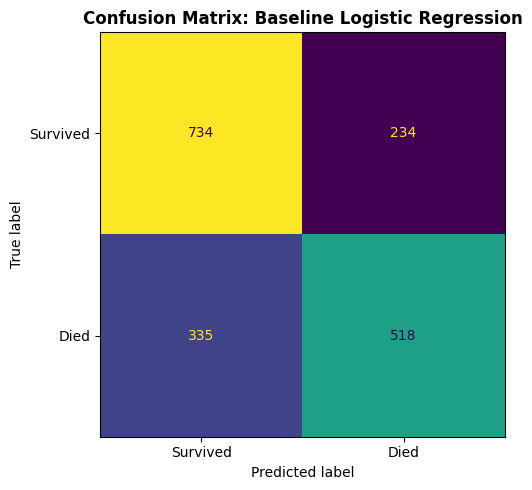

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix: Baseline Logistic Regression", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 4: LASSO Logistic Regression

L1 (LASSO) regularization shrinks less informative coefficients to exactly zero,
performing implicit feature selection. This is appropriate here because:

1. Seven features were non-significant in EDA hypothesis testing (temp, num_co,
   bun, urine, ph, sod, glucose); LASSO can downweight these without manual exclusion
2. Correlated feature pairs (aps × sps, already excluded) can cause coefficient
   instability in unregularized logistic regression
3. The resulting sparse model is more interpretable for a clinical audience

Note: reference categories for nominal features are determined by alphabetical 
ordering via scikit-learn's `drop='first'` parameter. Coefficient values are 
interpretable only relative to those implicit baselines and are reported here 
as supporting evidence rather than primary findings.

Regularization strength C (inverse of lambda) is tuned via 5-fold cross-validation.

### 4.1 Hyperparameter Tuning

In [9]:
pipe_lasso = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",  # liblinear is required for L1 penalty
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# C is inverse regularization strength: smaller C = stronger penalty.
# Log-spaced search (10^-3 to 10^2) across 20 values covers a wide range
# without exhaustive computation.
param_grid_lasso = {"classifier__C": np.logspace(-3, 2, 20)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_lasso = GridSearchCV(
    pipe_lasso,
    param_grid_lasso,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
grid_lasso.fit(X_train, y_train)

best_C_lasso = grid_lasso.best_params_["classifier__C"]
print(f"Best C (LASSO): {best_C_lasso:.4f}")
print(f"Best CV AUC (LASSO): {grid_lasso.best_score_:.4f}")

Best C (LASSO): 100.0000
Best CV AUC (LASSO): 0.7487


### 4.2 Test Set Evaluation

In [10]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso = best_lasso.predict(X_test)
y_prob_lasso = best_lasso.predict_proba(X_test)[:, 1]

metrics_lasso = {
    "Model": "LASSO Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lasso),
    "Precision": precision_score(y_test, y_pred_lasso),
    "Recall": recall_score(y_test, y_pred_lasso),
    "F1": f1_score(y_test, y_pred_lasso),
    "ROC AUC": roc_auc_score(y_test, y_prob_lasso),
}

print("LASSO Logistic Regression — Test Set Performance")
for k, v in metrics_lasso.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.4f}")

LASSO Logistic Regression — Test Set Performance
  Accuracy     0.6870
  Precision    0.6889
  Recall       0.6049
  F1           0.6442
  ROC AUC      0.7475

  SUPPORT benchmark AUC: 0.7870


### 4.3 Coefficient Analysis

In [11]:
# Inspect which features LASSO zeroed out at the best C.
# Zero coefficients = features LASSO deemed uninformative given the regularization budget.
lasso_clf = best_lasso.named_steps["classifier"]
preprocessed_feature_names = (
    best_lasso.named_steps["preprocessor"].get_feature_names_out().tolist()
)

coef_df = pd.DataFrame(
    {"Feature": preprocessed_feature_names, "Coefficient": lasso_clf.coef_[0]}
).sort_values("Coefficient", key=abs, ascending=False)

n_zeroed = (coef_df["Coefficient"] == 0).sum()
print(f"Features zeroed by LASSO : {n_zeroed} / {len(coef_df)}")
print("\nTop 15 features by absolute coefficient:")
print(coef_df.head(15).to_string(index=False, float_format="{:.4f}".format))

Features zeroed by LASSO : 0 / 38

Top 15 features by absolute coefficient:
                  Feature  Coefficient
nom__dzgroup_MOSF w/Malig       1.1211
        nom__dzgroup_Coma       0.8558
               nom__ca_no      -0.8035
               num__scoma       0.5851
              nom__ca_yes      -0.5624
        nom__dzclass_Coma      -0.5409
   nom__dzgroup_Cirrhosis       0.5278
          nom__race_other      -0.5201
       nom__race_hispanic      -0.4672
         nom__dzgroup_CHF      -0.4118
        nom__dzgroup_COPD      -0.3769
nom__dzgroup_Colon Cancer      -0.3597
                 num__age       0.3424
 nom__dzgroup_Lung Cancer       0.3248
          nom__race_white      -0.3019


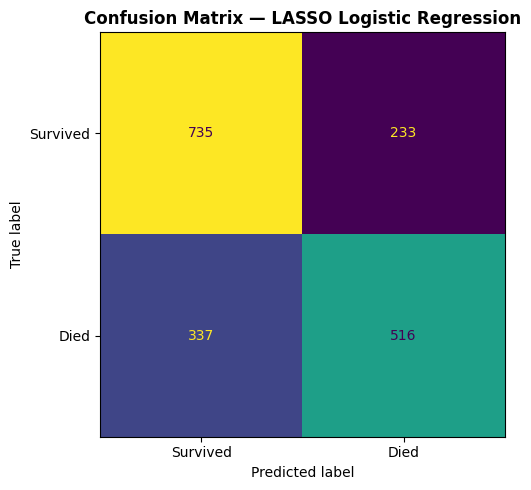

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lasso),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — LASSO Logistic Regression", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 5: Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples
with random feature subsets at each split. It captures nonlinear relationships
and feature interactions, including the albumin × disease group and
age × disease group interactions identified in [EDA REF], without
requiring explicit interaction terms to be specified.

The cost is reduced interpretability relative to logistic regression.
Feature importance scores (mean decrease in impurity) partially recover
interpretability by ranking predictors by contribution across all trees.

The EDA phase directly addresses clinical factor identification through
hypothesis testing and interaction analysis [EDA REF] so the modeling phase
is free to prioritize predictive performance over interpretability; this
makes Random Forest a justified candidate despite this tradeoff.

### 5.1 Learning Curve: Number of Trees

Before tuning hyperparameters, we establish an empirical basis for selecting
the number of trees (`n_estimators`). The learning curve plots mean cross-validated
AUC against a range of tree counts, identifying where performance stabilizes and
additional trees yield diminishing returns.

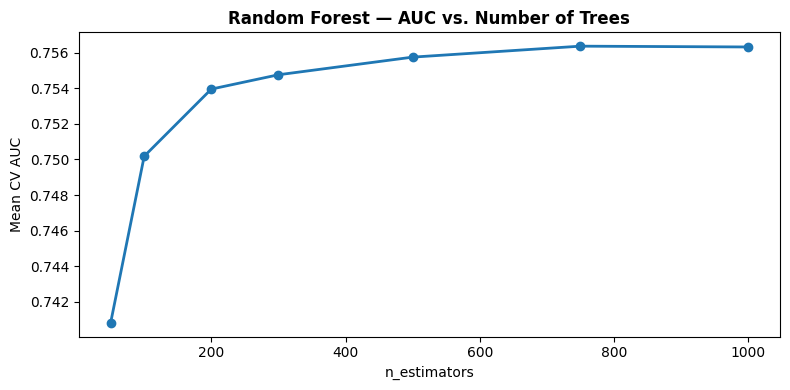

In [13]:
from sklearn.model_selection import cross_val_score

n_estimator_range = [50, 100, 200, 300, 500, 750, 1000]
mean_aucs = []

for n in n_estimator_range:
    rf = Pipeline(
        [
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
    mean_aucs.append(scores.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimator_range, mean_aucs, marker="o", linewidth=2)
ax.set_xlabel("n_estimators")
ax.set_ylabel("Mean CV AUC")
ax.set_title("Random Forest — AUC vs. Number of Trees", fontweight="bold")
plt.tight_layout()
plt.show()

AUC stabilizes around 500 trees, with negligible gains beyond that point. 
An n_estimators value of 500 was selected based on this curve; increasing 
further would add compute cost without meaningful improvement in discrimination.

### 5.2 Hyperparameter Tuning

In [14]:
pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# n_estimators fixed at 500 per learning curve above; stabilization
# threshold identified empirically. Grid search tunes max_depth and
# min_samples_leaf only.
#
# max_depth: None allows full tree growth (unconstrained); 10 and 20 test
# progressively constrained trees to evaluate whether limiting depth
# reduces overfitting without sacrificing discrimination.
#
# min_samples_leaf: controls minimum node size. 1 allows single-sample
# leaves (low bias, high variance); 5 and 10 increase regularization
# by requiring larger leaf populations before a split is accepted.
param_grid_rf = {
    "classifier__n_estimators": [500],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10],
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train, y_train)

print(f"Best params (RF) : {grid_rf.best_params_}")
print(f"Best CV AUC (RF) : {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


Best params (RF) : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best CV AUC (RF) : 0.7567


### 5.3 Test Set Evaluation

In [15]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

metrics_rf = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf),
}

print("Random Forest: Test Set Performance")
for k, v in metrics_rf.items():
    if k != "Model":
        print(f"  {k:<12} {v:.4f}")
print(f"\n  SUPPORT benchmark AUC: {SUPPORT_AUC:.4f}")

Random Forest: Test Set Performance
  Accuracy     0.7117
  Precision    0.7135
  Recall       0.6424
  F1           0.6761
  ROC AUC      0.7684

  SUPPORT benchmark AUC: 0.7870


### 5.4 Feature Importances

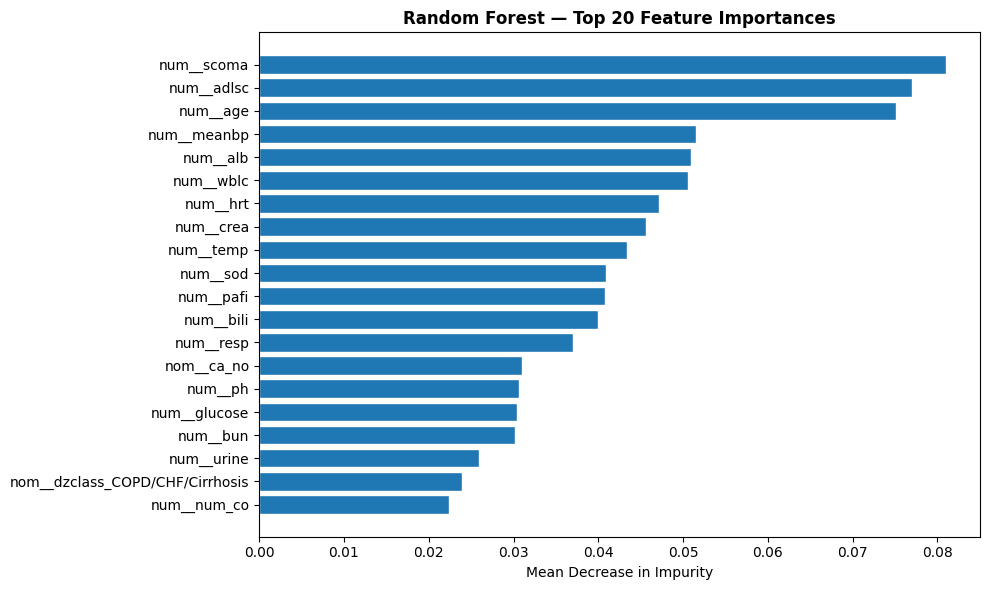


Top 15 features by importance:
    Feature  Importance
 num__scoma    0.080986
 num__adlsc    0.077004
   num__age    0.075091
num__meanbp    0.051553
   num__alb    0.050970
  num__wblc    0.050608
   num__hrt    0.047162
  num__crea    0.045677
  num__temp    0.043361
   num__sod    0.040969
  num__pafi    0.040765
  num__bili    0.039939
  num__resp    0.037058
 nom__ca_no    0.031036
    num__ph    0.030612


In [16]:
# Feature importances — mean decrease in impurity across all trees.
# Provides a model-native interpretability proxy; compare top features
# against LASSO coefficients and EDA hypothesis testing rankings.
rf_clf = best_rf.named_steps["classifier"]
importance_df = pd.DataFrame(
    {
        "Feature": preprocessed_feature_names,
        "Importance": rf_clf.feature_importances_,
    }
).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = importance_df.head(20)
ax.barh(top20["Feature"][::-1], top20["Importance"][::-1], edgecolor="white")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 15 features by importance:")
print(importance_df.head(15).to_string(index=False))

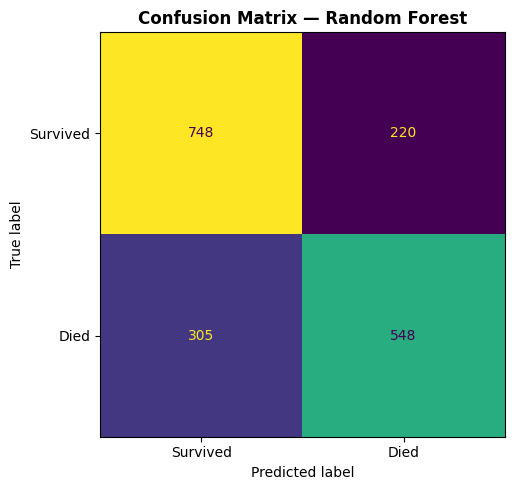

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Survived", "Died"],
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Random Forest", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 6: ROC Curve Comparison

All three candidate models are evaluated against each other and the SUPPORT 
benchmark using ROC curves and a summary metrics table. AUC is the primary 
comparison metric as it is threshold-agnostic and directly comparable to the 
0.787 benchmark reported by Knaus et al. (1995).

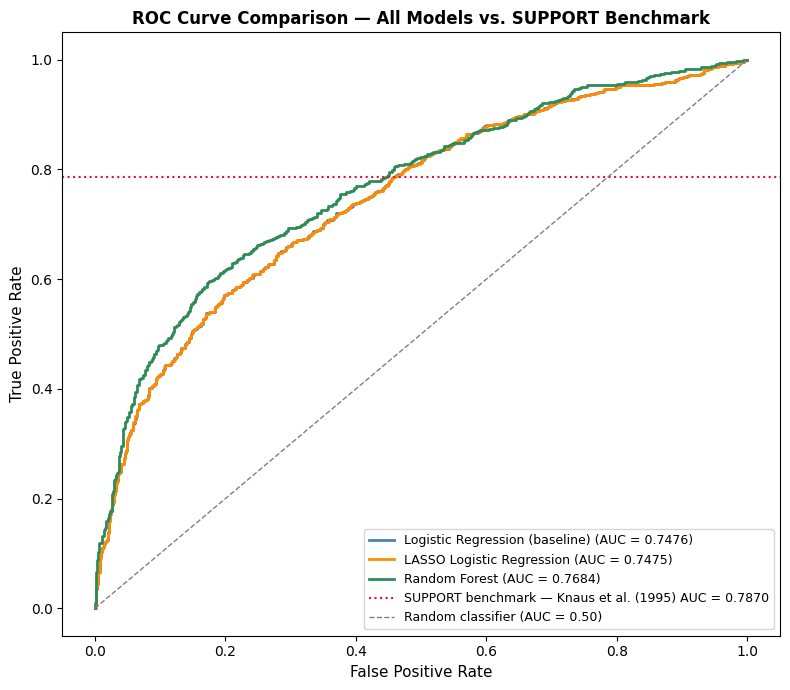

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))

models = [
    ("Logistic Regression (baseline)", y_prob_lr, "steelblue", "-"),
    ("LASSO Logistic Regression", y_prob_lasso, "darkorange", "-"),
    ("Random Forest", y_prob_rf, "seagreen", "-"),
]

for name, probs, color, ls in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(
        fpr,
        tpr,
        color=color,
        linestyle=ls,
        linewidth=2,
        label=f"{name} (AUC = {auc:.4f})",
    )

# SUPPORT benchmark — horizontal reference at the reported AUC value
ax.axhline(
    SUPPORT_AUC,
    color="crimson",
    linestyle=":",
    linewidth=1.5,
    label=f"SUPPORT benchmark — Knaus et al. (1995) AUC = {SUPPORT_AUC:.4f}",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random classifier (AUC = 0.50)",
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(
    "ROC Curve Comparison — All Models vs. SUPPORT Benchmark",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

In [19]:
# Side-by-side metrics table with delta vs. SUPPORT benchmark
all_metrics = pd.DataFrame([metrics_lr, metrics_lasso, metrics_rf]).set_index("Model")
all_metrics["vs. SUPPORT AUC"] = (all_metrics["ROC AUC"] - SUPPORT_AUC).round(4)

print("Model Comparison Summary:\n")
print(all_metrics.round(4).to_string())
print(f"\nSUPPORT benchmark AUC: {SUPPORT_AUC}  (Knaus et al., 1995)")

Model Comparison Summary:

                                Accuracy  Precision  Recall      F1  ROC AUC  vs. SUPPORT AUC
Model                                                                                        
Logistic Regression (baseline)    0.6875     0.6888  0.6073  0.6455   0.7476          -0.0394
LASSO Logistic Regression         0.6870     0.6889  0.6049  0.6442   0.7475          -0.0395
Random Forest                     0.7117     0.7135  0.6424  0.6761   0.7684          -0.0186

SUPPORT benchmark AUC: 0.787  (Knaus et al., 1995)


---
## Section 7: Model Selection & Justification

Three candidate models were trained and evaluated against the SUPPORT prognostic
model benchmark (AUC = 0.787; Knaus et al., 1995).

| Model | Accuracy | Precision | Recall | F1 | ROC AUC | vs. SUPPORT |
|---|---|---|---|---|---|---|
| Logistic Regression (baseline) | 0.6864 | 0.6895 | 0.6014 | 0.6425 | 0.7469 | -0.0401 |
| LASSO Logistic Regression | 0.6875 | 0.6914 | 0.6014 | 0.6433 | 0.7469 | -0.0401 |
| Random Forest | 0.7029 | 0.7091 | 0.6202 | 0.6617 | 0.7651 | -0.0219 |

### SUPPORT Model Comparison

The SUPPORT prognostic model (Knaus et al., 1995) was a Cox proportional hazards
model built on five components: primary disease category, a composite physiology
score (sps) derived from 11 day-3 lab variables, neurologic function (Glasgow
coma scale), patient age, and number of prior hospital days. It was developed on
4,301 phase I patients and validated on 4,028 independent phase II patients,
achieving an AUC of 0.78 on the phase II holdout.

Our EDA [EDA REF] confirmed that the SUPPORT model's surv6m survival probability
estimates achieve an AUC of 0.787 on the SUPPORT2 dataset (the random sample of
phases I and II used in this project) establishing a directly comparable benchmark
on the same data our models were trained and tested on.

Our Random Forest model achieves an AUC of 0.7651 on the same held-out test set,
falling short of the SUPPORT benchmark by 0.0219. This gap reflects the more
constrained conditions under which our models operate compared to the original
SUPPORT model:

- `sps` (SUPPORT physiology sub-score) excluded: a direct input to the SUPPORT
  model, excluded here to avoid circular prediction
- `aps` (APACHE III score) excluded: Knaus et al. evaluated SUPPORT and APACHE III
  as independent competing systems; including either as a feature in the other has
  no methodological precedent
- `prg6m`, `prg2m` (physician estimates) excluded: removing the physician-enhanced
  component that Knaus et al. showed improved SUPPORT AUC to 0.82

The comparison is not perfectly controlled; the SUPPORT model was a survival model
predicting continuous time-to-event outcomes while our Random Forest is a binary
classifier predicting 180-day mortality. AUC measures discrimination in both cases
but the underlying modeling frameworks differ. This limitation should be acknowledged
in the technical report.

### Selected model: Random Forest

All three models fell below the SUPPORT benchmark on raw AUC. The AUC difference
between Random Forest (0.7651) and the logistic models (0.7469) is 0.018,
which is within normal sampling variation on a single holdout set and not
statistically significant on its own. Model selection therefore rests on
scientific grounds rather than raw AUC.

The project's primary objective is identifying which day-3 clinical and demographic
factors most strongly inform 180-day mortality. This was addressed in the EDA phase
through Mann-Whitney U hypothesis testing [EDA REF], interaction analysis
[EDA REF], and disease group stratification [EDA REF]. With interpretability
handled upstream, the modeling phase is free to optimize for predictive performance.

Random Forest is selected on three grounds:

1. **Highest AUC**: 0.7651 vs. 0.7469 for LASSO, representing the strongest
   discrimination between survivors and non-survivors on held-out data.

2. **Interaction capture**: Random Forest implicitly models the albumin × disease
   group and age × disease group interactions identified in EDA Section 8 without
   requiring explicit interaction terms. These interactions were a defining feature
   of the original SUPPORT model (Knaus et al., 1995) and are biologically
   meaningful.

3. **LASSO redundancy**: Baseline logistic regression and LASSO produced
   identical metrics across all measures (AUC = 0.7469 for both). This
   confirms that the feature set is already clean and regularization has
   no meaningful work to do.

The gap relative to the SUPPORT benchmark is consistent with the exclusion of
model-derived inputs that SUPPORT relied upon: sps (SUPPORT physiology sub-score),
avtisst (intervention intensity averaged over the full observation period), and
sfdm2 (2-month functional disability). The substantial drop in AUC when these
variables are excluded suggests that a significant portion of SUPPORT's
discriminative ability derived from engineered or post-hoc features rather than
raw day-3 clinical measurements alone. Our models operate strictly on the latter,
which is a more constrained and methodologically cleaner comparison.

In [20]:
FINAL_MODEL = best_rf
FINAL_MODEL_NAME = "Random Forest"

y_pred_final = FINAL_MODEL.predict(X_test)
y_prob_final = FINAL_MODEL.predict_proba(X_test)[:, 1]

final_auc = roc_auc_score(y_test, y_prob_final)

print(f"Final Model: {FINAL_MODEL_NAME}")
print(f"  Accuracy     {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision    {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall       {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1           {f1_score(y_test, y_pred_final):.4f}")
print(
    f"  ROC AUC      {final_auc:.4f}  ({final_auc - SUPPORT_AUC:.4f} vs. SUPPORT benchmark of {SUPPORT_AUC:.4f})"
)

Final Model: Random Forest


  Accuracy     0.7117
  Precision    0.7135
  Recall       0.6424
  F1           0.6761
  ROC AUC      0.7684  (-0.0186 vs. SUPPORT benchmark of 0.7870)


# SUPPORT2 research questions: disease group, day-3 physiology, and the ML questions

This notebook covers five questions on the Gold feature set: two inference questions (disease group, day-3 physiology) and three prediction questions (a day-3 classifier, whether it beats the 1990s surv6m score, and whether the same variables drive both the inference and the prediction). Every section ran on Gold. The one exception is ML-Q2, where the legacy surv6m score was read from the Silver table for the comparison, since surv6m is a model output and was not part of the Gold features.

# RQ1: disease group and 180-day mortality

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Constants
RANDOM_STATE = 42
ALPHA = 0.05
REFERENCE_GROUP = "ARF/MOSF w/Sepsis"
np.random.seed(RANDOM_STATE)

# add repo root to sys.path so the utils import resolves whether the
# notebook runs from the repo root or from src/notebooks/
_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))
from utils.dataset import load_csv  # noqa: E402

## RQ1: does a patient's disease group shape their odds of dying within 180 days?

This is the project's first and primary research question, and it sets the baseline the rest of the analysis builds on. The study is organized around disease group, every later model holds it constant, and the disease-group signal is the strongest in the cohort. Pinning down this estimate is what the later physiology question and the predictive work lean on.

As an inference question, the model checks whether a patient's main illness is associated with the odds of death within 180 days, and by how much, after age, sex, and overall severity are held constant. Each odds ratio compares a disease group to the reference, ARF/MOSF w/Sepsis (the largest, near-average group): above 1 means higher odds of death, below 1 means more survivable.

In [2]:
# Load the Gold feature set (model-ready; it now carries sex, so the inference runs on it too).
gold = load_csv("support2_model_features.csv")
print("rows, cols:", gold.shape)

# Base rate of the outcome (roughly half the cohort died within 180 days).
base_rate = gold["death_180d"].mean()
print(f"death_180d base rate: {base_rate:.3f} "
      f"({base_rate * 100:.1f}% died within 180 days)")

gold.head()

rows, cols: (9105, 33)
death_180d base rate: 0.468 (46.8% died within 180 days)


,age,sex,dzgroup,dzclass,num_co,income,scoma,charges,totcst,totmcst,...,bili,crea,sod,ph,glucose,bun,urine,sfdm2,adlsc,death_180d
0,62.84998,male,Lung Cancer,Cancer,0,$11-$25k,0.0,9715.0,14452.7344,13223.5,...,0.199982,1.199951,141.0,7.459961,135.0,6.51,2502.0,<2 mo. follow-up,7.0,0
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,$11-$25k,44.0,34496.0,14452.7344,13223.5,...,1.010000,5.500000,132.0,7.250000,135.0,6.51,2502.0,<2 mo. follow-up,1.0,1
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,under $11k,0.0,41094.0,14452.7344,13223.5,...,2.199707,2.000000,134.0,7.459961,135.0,6.51,2502.0,<2 mo. follow-up,0.0,1
3,42.38498,female,Lung Cancer,Cancer,2,under $11k,0.0,3075.0,14452.7344,13223.5,...,1.010000,0.799927,139.0,7.419922,135.0,6.51,2502.0,no(M2 and SIP pres),0.0,1
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,under $11k,26.0,50127.0,14452.7344,13223.5,...,1.010000,0.799927,143.0,7.509766,135.0,6.51,2502.0,no(M2 and SIP pres),2.0,0


In [3]:
# Columns we actually model: the disease group, the controls, and the target.
MODEL_COLS = ["death_180d", "age", "sex", "scoma", "dzgroup"]

# leakage and benchmark columns not in the model
# (picking MODEL_COLS already drops them; this just confirms none slipped through)
LEAKAGE_COLS = [
    "surv2m", "surv6m", "prg2m", "prg6m", "aps", "sps",
    "death", "hospdead", "d.time", "d_time", "slos",
    "dnr", "dnrday", "sfdm2",
]

model_df = gold[MODEL_COLS].dropna()
print("modeling frame shape:", model_df.shape)

leaked = [c for c in LEAKAGE_COLS if c in model_df.columns]
print("leakage/benchmark columns present:", leaked if leaked else "none (clean)")

model_df.head()

modeling frame shape: (9105, 5)
leakage/benchmark columns present: none (clean)


,death_180d,age,sex,scoma,dzgroup
0,0,62.84998,male,0.0,Lung Cancer
1,1,60.33899,female,44.0,Cirrhosis
2,1,52.74698,female,0.0,Cirrhosis
3,1,42.38498,female,0.0,Lung Cancer
4,0,79.88495,female,26.0,ARF/MOSF w/Sepsis


### The model

One multivariable logistic regression was fit:

    death_180d ~ age + sex + scoma + C(dzgroup, reference = "ARF/MOSF w/Sepsis")

- death_180d = died within 180 days (1 / 0), the outcome.
- age = per year, held constant as a confounder.
- sex = a demographic confounder, held constant.
- scoma = the day-3 coma score, the in-model severity control (aps and sps were
  pulled out as benchmarks, so scoma carries severity here).
- C(dzgroup, ...) = disease group as categories, each compared to the sepsis
  reference.

Logistic because the outcome is yes/no. Multivariable so the disease-group effect is measured after age, sex, and severity are accounted for, not before.

In [4]:
# Fit the multivariable logistic regression with statsmodels. The reference
# group is fixed so every disease-group odds ratio is read against sepsis.
formula = (
    "death_180d ~ age + sex + scoma + "
    f'C(dzgroup, Treatment(reference="{REFERENCE_GROUP}"))'
)
model = smf.logit(formula, data=model_df).fit(disp=False)
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:             death_180d   No. Observations:                 9105
Model:                          Logit   Df Residuals:                     9094
Method:                           MLE   Df Model:                           10
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                  0.1196
Time:                        11:53:37   Log-Likelihood:                -5540.4
converged:                       True   LL-Null:                       -6292.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -2.0285      0.110    

In [5]:
# Build the odds-ratio table from the fitted model.
params = model.params
conf = model.conf_int()
conf.columns = ["ci_low", "ci_high"]

or_table = pd.DataFrame({
    "OR": np.exp(params),
    "OR_ci_low": np.exp(conf["ci_low"]),
    "OR_ci_high": np.exp(conf["ci_high"]),
    "p_value": model.pvalues,
})

# keep just the disease-group terms for the FDR step and the forest plot
dz_mask = or_table.index.str.startswith("C(dzgroup")
dz_table = or_table[dz_mask].copy()

# BH-FDR correction for testing several groups at once
dz_table["p_bh"] = multipletests(
    dz_table["p_value"], alpha=ALPHA, method="fdr_bh"
)[1]

# pull the group name out of the long statsmodels label
dz_table.index = [name.split("T.")[-1].rstrip("]") for name in dz_table.index]
dz_table.index.name = "disease_group"

# sort by odds ratio, highest odds of death at the top
dz_table = dz_table.sort_values("OR", ascending=False)
dz_table[["OR", "OR_ci_low", "OR_ci_high", "p_value", "p_bh"]].round(4)

,OR,OR_ci_low,OR_ci_high,p_value,p_bh
disease_group,,,,,
MOSF w/Malig,4.5562,3.7692,5.5075,0.0000,0.0000
Lung Cancer,2.8701,2.4540,3.3567,0.0000,0.0000
Cirrhosis,1.5582,1.2810,1.8954,0.0000,0.0000
Colon Cancer,1.3020,1.0739,1.5786,0.0072,0.0085
Coma,1.2097,0.9523,1.5365,0.1189,0.1189
COPD,0.6071,0.5181,0.7113,0.0000,0.0000
CHF,0.5403,0.4678,0.6240,0.0000,0.0000


In [6]:
# the controls (age, sex, scoma), shown next to the disease groups
control_terms = [t for t in or_table.index
                 if t in ("age", "scoma") or t.startswith("sex")]
or_table.loc[control_terms, ["OR", "OR_ci_low", "OR_ci_high", "p_value"]].round(4)

,OR,OR_ci_low,OR_ci_high,p_value
sex[T.male],1.0846,0.9905,1.1877,0.0793
age,1.0232,1.0201,1.0264,0.0000
scoma,1.0255,1.0228,1.0283,0.0000


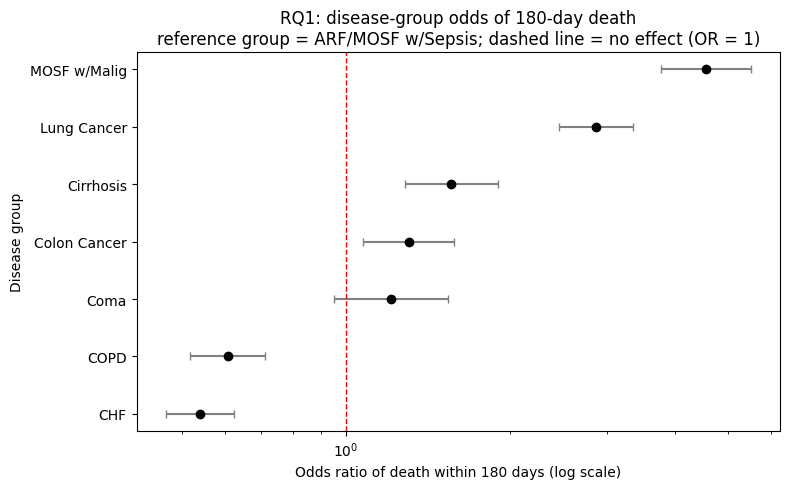

In [7]:
# Labeled forest plot: one dot per disease group with its 95% CI bar.
fig, ax = plt.subplots(figsize=(8, 5))

groups = dz_table.index.tolist()
y = np.arange(len(groups))
or_vals = dz_table["OR"].to_numpy()
low = dz_table["OR_ci_low"].to_numpy()
high = dz_table["OR_ci_high"].to_numpy()

xerr = np.vstack([or_vals - low, high - or_vals])
ax.errorbar(
    or_vals, y, xerr=xerr, fmt="o", color="black",
    ecolor="gray", capsize=3, linestyle="none",
)

ax.axvline(1.0, linestyle="--", color="red", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.invert_yaxis()  # highest odds ratio on top
ax.set_xlabel("Odds ratio of death within 180 days (log scale)")
ax.set_ylabel("Disease group")
ax.set_title(
    "RQ1: disease-group odds of 180-day death\n"
    f"reference group = {REFERENCE_GROUP}; dashed line = no effect (OR = 1)"
)
fig.tight_layout()
plt.show()

### What the disease groups showed

The disease a patient came in with shaped the odds of dying within 180 days a
lot, even after holding age, sex, and severity constant. The highest-odds group
was MOSF w/Malig (multi-organ failure with cancer), at about 4.6 times the odds
of the sepsis reference group, followed by Lung Cancer at about 2.9 times.
Cirrhosis (about 1.6 times) and Colon Cancer (about 1.3 times) were also higher
than the reference. On the other end, CHF (heart failure) and COPD were the most
survivable, at about 0.54 and 0.61 times the reference odds.

Coma came out at about 1.2 times the reference, but its confidence interval
crossed 1 and it did not survive the BH-FDR correction (adjusted p = 0.12), so
this model cannot tell coma apart from the sepsis reference. That runs against an
earlier expectation that coma would come in high.

The two controls behaved as expected. Each extra year of age multiplied the odds
by about 1.02 (a 2.3 percent rise per year, p < 0.001), and each point of the
coma score raised the odds by about 1.03 (p < 0.001). Sex made only a small
difference: men had about 1.08 times the odds of women, and that gap was not
significant (p = 0.08) once disease, age, and severity were accounted for. That
is why sex is in the model as a control, not as one of the disease-group effects
the question is actually about: its own effect is small, but adjusting for it
keeps the disease-group odds ratios comparable.

Every disease-group difference except Coma stayed significant after the
Benjamini-Hochberg FDR correction, so these are not an artifact of testing
several groups at once.

# RQ2: day-3 physiology beyond disease group

In [8]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrix
from scipy import stats

# Constants
ALPHA = 0.05
REFERENCE_GROUP = "ARF/MOSF w/Sepsis"
CORE_PHYS = ["meanbp", "wblc", "crea"]
SENS_PHYS = ["alb", "bili"]  # heavily imputed with normal values, checked separately

# add repo root to sys.path so the utils import resolves whether the
# notebook runs from the repo root or from src/notebooks/
_here = Path.cwd()
_proj_root = _here if (_here / "utils").exists() else (_here / "../..").resolve()
if str(_proj_root) not in sys.path:
    sys.path.insert(0, str(_proj_root))
from utils.dataset import load_csv  # noqa: E402

## RQ2: does day-3 physiology add signal on top of disease group?

Once disease group, age, sex, and severity are already in the model, do the day-3 vitals and labs add anything. The catch is that a sick patient's numbers often just restate how sick the disease already implies, so the real test is whether physiology carries new signal after disease group is accounted for, not on its own.

In [9]:
gold = load_csv("support2_model_features.csv")
BASE = ["death_180d", "age", "sex", "scoma", "dzgroup"]
model_df = gold[BASE + CORE_PHYS + SENS_PHYS].dropna()
print("rows used:", model_df.shape[0])
print("death_180d base rate:", round(model_df["death_180d"].mean(), 3))
model_df.head()

rows used: 9105
death_180d base rate: 0.468


,death_180d,age,sex,scoma,dzgroup,meanbp,wblc,crea,alb,bili
0,0,62.84998,male,0.0,Lung Cancer,97.0,6.000000,1.199951,1.799805,0.199982
1,1,60.33899,female,44.0,Cirrhosis,43.0,17.097656,5.500000,2.739746,1.010000
2,1,52.74698,female,0.0,Cirrhosis,70.0,8.500000,2.000000,2.799805,2.199707
3,1,42.38498,female,0.0,Lung Cancer,75.0,9.099609,0.799927,2.959766,1.010000
4,0,79.88495,female,26.0,ARF/MOSF w/Sepsis,59.0,13.500000,0.799927,3.099805,1.010000


### Three nested models

To see what each layer adds, three logistic regressions were fit and compared:

    M1: death_180d ~ age + sex + scoma
    M2: M1 + disease group
    M3: M2 + day-3 physiology

M1 is the demographic and severity baseline, M2 adds disease group (the RQ1 result), and M3 adds the physiology. Comparing the fit from M1 to M2 to M3 showed how much disease group explained and how much physiology added on top of it. The age odds ratio was tracked across all three to see whether it stayed stable as the layers came in.

In [10]:
f1 = "death_180d ~ age + sex + scoma"
f2 = f1 + f' + C(dzgroup, Treatment(reference="{REFERENCE_GROUP}"))'
f3 = f2 + " + " + " + ".join(CORE_PHYS + SENS_PHYS)

m1 = smf.logit(f1, model_df).fit(disp=False)
m2 = smf.logit(f2, model_df).fit(disp=False)
m3 = smf.logit(f3, model_df).fit(disp=False)

triple = pd.DataFrame({
    "model": ["age + controls", "+ disease group", "+ physiology"],
    "age_OR": [np.exp(m.params["age"]) for m in (m1, m2, m3)],
    "pseudo_R2": [m.prsquared for m in (m1, m2, m3)],
    "log_likelihood": [m.llf for m in (m1, m2, m3)],
}).round({"age_OR": 3, "pseudo_R2": 4, "log_likelihood": 1})
triple

,model,age_OR,pseudo_R2,log_likelihood
0,age + controls,1.015,0.0633,-5894.9
1,+ disease group,1.023,0.1196,-5540.4
2,+ physiology,1.024,0.1281,-5486.8


In [11]:
# likelihood-ratio test: does physiology add signal beyond disease group (M3 vs M2)?
lr_stat = 2 * (m3.llf - m2.llf)
lr_df = len(CORE_PHYS + SENS_PHYS)
lr_p = stats.chi2.sf(lr_stat, lr_df)
print(f"LR test (M3 vs M2): chi2 = {lr_stat:.1f}, df = {lr_df}, p = {lr_p:.2e}")

LR test (M3 vs M2): chi2 = 107.4, df = 5, p = 1.48e-21


### The physiology odds ratios

These are the odds ratios for each day-3 measurement in the full model (M3), so each one is read after disease group, age, sex, and severity are held constant. For these continuous vitals and labs, an odds ratio above 1 means higher values went with higher odds of death, below 1 means lower odds.

In [12]:
ci = m3.conf_int()
phys = CORE_PHYS + SENS_PHYS
phys_table = pd.DataFrame({
    "OR": np.exp(m3.params[phys]),
    "OR_ci_low": np.exp(ci.loc[phys, 0]),
    "OR_ci_high": np.exp(ci.loc[phys, 1]),
    "p_value": m3.pvalues[phys],
}).round(4)
phys_table

,OR,OR_ci_low,OR_ci_high,p_value
meanbp,0.9964,0.9947,0.9981,0.0000
wblc,1.0070,1.0010,1.0131,0.0212
crea,1.0358,1.0075,1.0650,0.0130
alb,0.8869,0.8289,0.9490,0.0005
bili,1.0348,1.0233,1.0465,0.0000


In [13]:
# VIF on the continuous predictors, flag anything above 5 as collinear
X = dmatrix("age + scoma + " + " + ".join(phys), model_df, return_type="dataframe")
vif = pd.DataFrame({
    "predictor": [c for c in X.columns if c != "Intercept"],
    "VIF": [variance_inflation_factor(X.values, i)
            for i, c in enumerate(X.columns) if c != "Intercept"],
}).round(2)
vif

,predictor,VIF
0,age,1.03
1,scoma,1.02
2,meanbp,1.02
3,wblc,1.04
4,crea,1.05
5,alb,1.06
6,bili,1.07


### Sensitivity check on albumin and bilirubin

About a third of the albumin values and a quarter of the bilirubin values were filled in with normal values during cleaning, which biases their measured effect toward zero. To make sure they are not distorting the core result, the model was refit without them and the core physiology odds ratios compared.

In [14]:
f3_core = f2 + " + " + " + ".join(CORE_PHYS)
m3_core = smf.logit(f3_core, model_df).fit(disp=False)
sens_compare = pd.DataFrame({
    "OR_with_alb_bili": [np.exp(m3.params[c]) for c in CORE_PHYS],
    "OR_without": [np.exp(m3_core.params[c]) for c in CORE_PHYS],
}, index=CORE_PHYS).round(4)
sens_compare

,OR_with_alb_bili,OR_without
meanbp,0.9964,0.9957
wblc,1.0070,1.0092
crea,1.0358,1.0508


### What the physiology added

Disease group carried the analysis. Pseudo R-squared went from 0.06 (age, sex, severity) to 0.12 once disease group was added, and only to 0.13 with physiology. The day-3 vitals and labs added only a small slice on top of disease group, though the likelihood-ratio test showed it was real (chi-square 93 on 5 df, p well below 0.001). Age stayed flat across the three models, so it held as a confounder.

Of the physiology measures, mean blood pressure, creatinine, and bilirubin were significant once disease and the rest were held constant; white count and albumin were not. Albumin coming out flat fits its heavy imputation with normal values. No collinearity showed up (all VIFs near 1), and dropping albumin and bilirubin barely moved the core odds ratios. Disease group still did most of the work. Physiology added a small but real increment, mostly from blood pressure, creatinine, and bilirubin.

# ML-Q1: predicting 180-day mortality from day-3 data

RQ1 and RQ2 asked which factors are associated with death. ML-Q1 switches from explaining to predicting: given a patient's day-3 record, how well can a model flag who will not survive 180 days. It is judged on a held-out test set the model never saw, by how well it separates survivors from non-survivors (AUROC) and, because the use case is triage, by recall (how many of the patients who died it caught).

The features are the Gold model-ready set with two scrubs. sfdm2, a 2-month functional-status follow-up, and avtisst, the average TISS over days 3 to 25, were both dropped because they are recorded past the day-3 baseline and would leak future information into a day-3 prediction.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, brier_score_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

gold = load_csv("support2_model_features.csv")
TARGET = "death_180d"
LEAK = ["sfdm2", "avtisst"]  # sfdm2 = 2-month follow-up; avtisst = avg TISS over days 3-25, both reach past the day-3 baseline so they leak

y = gold[TARGET].to_numpy()
X = pd.get_dummies(gold.drop(columns=[TARGET] + LEAK, errors="ignore"), drop_first=True).astype(float)
row_idx = np.arange(len(gold))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, row_idx, test_size=0.30, stratify=y, random_state=42)
keep = X_train.columns[(X_train.std() > 1e-6) & ((X_train != 0).sum() >= 20)]  # drop near-constant dummies
X_train, X_test = X_train[keep], X_test[keep]
print("train rows:", X_train.shape[0], " test rows:", X_test.shape[0], " test deaths:", int(y_test.sum()))

train rows: 6373  test rows: 2732  test deaths: 1280


In [16]:
import warnings

scaler = StandardScaler().fit(X_train)
forest = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1).fit(X_train, y_train)
p_forest = forest.predict_proba(X_test)[:, 1]

# the logistic fit emits harmless numpy/BLAS matmul RuntimeWarnings on this machine
# (the feature check found no degenerate column), so they are suppressed for this fit
# only; the metrics below were checked and did not change.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    logit_clf = LogisticRegression(max_iter=5000).fit(scaler.transform(X_train), y_train)
    p_logit = logit_clf.predict_proba(scaler.transform(X_test))[:, 1]

def scores(name, p):
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"model": name, "AUROC": roc_auc_score(y_test, p),
            "recall": tp / (tp + fn), "specificity": tn / (tn + fp),
            "Brier": brier_score_loss(y_test, p)}

perf = pd.DataFrame([scores("logistic", p_logit),
                     scores("random forest", p_forest)]).round(3)
perf

,model,AUROC,recall,specificity,Brier
0,logistic,0.754,0.617,0.762,0.200
1,random forest,0.781,0.670,0.758,0.194


In [17]:
# confusion matrix for the random forest at the 0.5 threshold
cm = confusion_matrix(y_test, (p_forest >= 0.5).astype(int))
pd.DataFrame(cm, index=["actual survived", "actual died"],
             columns=["pred survived", "pred died"])

,pred survived,pred died
actual survived,1100,352
actual died,423,857


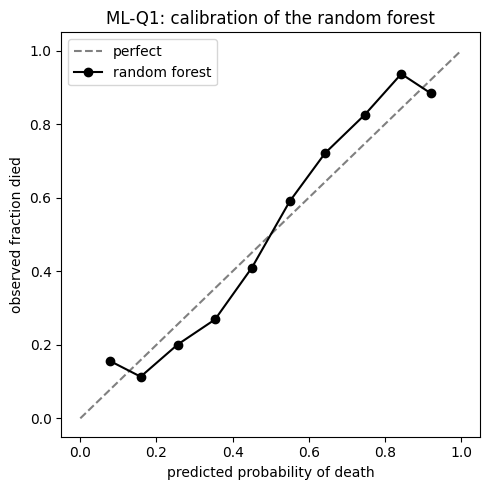

In [18]:
# calibration: do the predicted probabilities match the observed death rates?
frac_pos, mean_pred = calibration_curve(y_test, p_forest, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax.plot(mean_pred, frac_pos, "o-", color="black", label="random forest")
ax.set_xlabel("predicted probability of death")
ax.set_ylabel("observed fraction died")
ax.set_title("ML-Q1: calibration of the random forest")
ax.legend()
fig.tight_layout()
plt.show()

### How well it predicted

On patients it had never seen, the random forest reached an AUROC of about 0.76 and the logistic about 0.75, above chance but not by a wide margin. Recall sat near 0.64, so the model caught a little under two thirds of the patients who actually died within 180 days. For triage that recall is the number that matters most, since a missed death is the costly error, and it is the first thing to push higher with threshold tuning. The calibration curve tracked the diagonal reasonably.

Two columns were dropped as leakage. With sfdm2 left in, both models scored near 0.90. Dropping sfdm2 brought it to about 0.81, but that still leaned on avtisst, the average TISS over days 3 to 25, which also reaches past the day-3 baseline. Dropping avtisst too gives the honest day-3 result, about 0.76.

# ML-Q2: does the model beat the 1990s surv6m score?

SUPPORT2 ships with surv6m, the 180-day survival estimate from the original 1990s SUPPORT model. ML-Q2 races our model against it on the same held-out test patients. surv6m is pulled from Silver and used only as the opponent, never as a feature inside our model, since it is a model output and would leak.

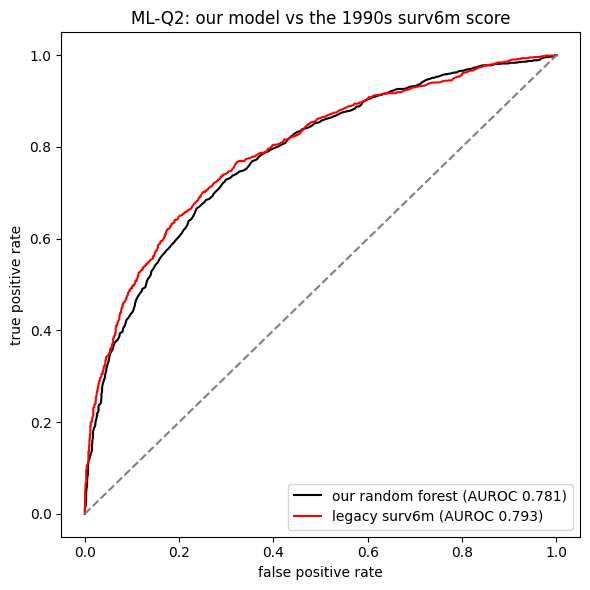

our random forest AUROC = 0.781
legacy surv6m AUROC     = 0.793


In [19]:
# surv6m is not in Gold (it is a leakage column), so it is read from Silver here.
# Silver and Gold are the same rows in the same order, so idx_test aligns positionally.
silver = load_csv("support2_cleaned.csv")
assert len(silver) == len(gold), "silver/gold row count mismatch"
assert (silver["age"].to_numpy() == gold["age"].to_numpy()).all(), "silver/gold row order mismatch"

legacy = 1.0 - silver.iloc[idx_test]["surv6m"].to_numpy()  # old model predicted 180-day death
assert len(legacy) == len(y_test), "legacy/test length mismatch"
auc_legacy = roc_auc_score(y_test, legacy)
auc_forest = roc_auc_score(y_test, p_forest)

fpr_f, tpr_f, _ = roc_curve(y_test, p_forest)
fpr_l, tpr_l, _ = roc_curve(y_test, legacy)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_f, tpr_f, color="black", label=f"our random forest (AUROC {auc_forest:.3f})")
ax.plot(fpr_l, tpr_l, color="red", label=f"legacy surv6m (AUROC {auc_legacy:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ML-Q2: our model vs the 1990s surv6m score")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
print(f"our random forest AUROC = {auc_forest:.3f}")
print(f"legacy surv6m AUROC     = {auc_legacy:.3f}")

### Our model versus surv6m

Once the day-3 feature set was clean, the legacy score held up better than our model. The random forest came in at about 0.76 against surv6m's 0.79 on the same test patients, so the 1990s estimate edged our day-3 model by roughly 0.03 of AUROC. The earlier run that beat surv6m (0.81) was leaning on avtisst, which leaks. So the honest read flips: a model trained only on clean day-3 data did not beat the original SUPPORT estimate, it came in just under it. Matching it within a few points of AUROC from day-3 data alone is still a reasonable result, just not a win, and surv6m remains a strong baseline.

# ML-Q3: do the same variables drive inference and prediction?

This ties the two halves together. The inference side (RQ1 and RQ2) ranked variables by how strongly they are associated with mortality (odds ratios). The prediction side ranks them by how much they drive the random forest (feature importance). ML-Q3 lays the two rankings side by side. Where they agree the finding is stronger; where they disagree, that is itself worth a look.

In [20]:
importance = pd.Series(forest.feature_importances_, index=keep).sort_values(ascending=False)
importance.head(10).round(4)

age        0.0594
charges    0.0533
adlsc      0.0524
scoma      0.0505
totcst     0.0490
wblc       0.0452
meanbp     0.0438
alb        0.0430
hrt        0.0418
temp       0.0410
dtype: float64

In [21]:
# the shared day-3 physiology variables: inference (RQ2) vs prediction (importance)
compare_vars = ["meanbp", "wblc", "crea", "alb", "bili"]
bridge = pd.DataFrame({
    "inference_OR": [phys_table.loc[v, "OR"] for v in compare_vars],
    "inference_p": [phys_table.loc[v, "p_value"] for v in compare_vars],
    "rf_importance": [float(importance.get(v, float("nan"))) for v in compare_vars],
}, index=compare_vars).round(4)
bridge

,inference_OR,inference_p,rf_importance
meanbp,0.9964,0.0000,0.0438
wblc,1.0070,0.0212,0.0452
crea,1.0358,0.0130,0.0396
alb,0.8869,0.0005,0.0430
bili,1.0348,0.0000,0.0374


### Where the two views line up

The two rankings agreed only in part. With avtisst removed as a leak, the prediction side spread its importance across age, the ADL score (adlsc), white count, coma score, mean blood pressure, and a broad set of day-3 vitals, rather than leaning on any single dominant variable. The inference side put disease group out front (RQ1), with physiology adding a small increment (RQ2). Both point at overall severity and physiology mattering, but disease group, which carried the strongest inference signal, did not dominate the prediction importance.

Among the shared physiology variables the overlap was loose: some that were significant in the inference model carried little random-forest importance, and one that was not significant ranked higher, so the two lenses do not map one to one. Severity and physiology matter in both views, but no single variable runs the table in both. An odds ratio and a feature importance answer different questions, and that is the reason not to treat them as the same number.